## Topic Modeling with LDA & Social Network Analysis (SNA)


> **Catatan revisi:** Versi ini menambahkan blok konfigurasi terpusat, statistik
> deskriptif di setiap tahap, tabel & figur siap-publikasi (disimpan otomatis ke
> `output/figures/` dan `output/tables/`), serta beberapa perbaikan efisiensi/konsistensi
> kode. Metodologi inti (LDA, coherence C_v, User-Topic Matrix, cosine similarity,
> community detection, bridge-user entropy) **tidak diubah** — lihat ringkasan review
> yang menyertai notebook ini untuk detail dan justifikasi setiap perubahan.

In [1]:
import nltk
import gensim
from gensim import corpora, models
from gensim.models.coherencemodel import CoherenceModel
from gensim.models.phrases import Phrases, Phraser
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import re
import os
import random
import pandas as pd
import numpy as np
import scipy.stats
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.lines import Line2D
from sklearn.metrics.pairwise import cosine_similarity
import networkx as nx
import networkx.algorithms.community as nx_comm

# Download NLTK resources
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)


[nltk_data] Error loading stopwords: <urlopen error [Errno 8] nodename
[nltk_data]     nor servname provided, or not known>
[nltk_data] Error loading punkt: <urlopen error [Errno 8] nodename nor
[nltk_data]     servname provided, or not known>
[nltk_data] Error loading punkt_tab: <urlopen error [Errno 8] nodename
[nltk_data]     nor servname provided, or not known>


False

## ⚙️ Konfigurasi & Reproducibility

Seluruh parameter yang mempengaruhi hasil eksperimen (random seed, jumlah passes LDA,
rentang pencarian k untuk coherence, parameter bigram, threshold similarity, dsb.)
dikumpulkan di satu tempat agar penelitian ini mudah direproduksi dan diaudit.
Cell-cell selanjutnya membaca nilainya dari dictionary `CONFIG` di bawah — ubah di sini,
bukan di tempat lain di notebook.

In [2]:
CONFIG = {
    # --- Reproducibility ---
    "RANDOM_SEED": 42,

    # --- Bigram phrase model ---
    "BIGRAM_MIN_COUNT": 5,
    "BIGRAM_THRESHOLD": 10,

    # --- Dictionary filtering (Bag-of-Words) ---
    "DICT_NO_BELOW": 3,      # buang token yang muncul di kurang dari N dokumen
    "DICT_NO_ABOVE": 0.85,   # buang token yang muncul di lebih dari X% dokumen

    # --- LDA training & coherence search ---
    "LDA_PASSES": 10,
    "COHERENCE_START_K": 1,
    "COHERENCE_LIMIT_K": 10,
    "COHERENCE_METRIC": "c_v",

    # --- Qualitative validation samples ---
    "N_TOPIC_SAMPLES": 3,        # sampel tweet per topik
    "N_COMMUNITY_SAMPLES": 3,    # sampel tweet per komunitas
    "N_TOP_USERS_PER_TOPIC": 5,  # top users ditampilkan per topik

    # --- User similarity network ---
    "SIMILARITY_THRESHOLD": 0.8,

    # --- Bridge-user detection ---
    "BRIDGE_ENTROPY_STD_MULTIPLIER": 1.0,  # bridge jika entropy > mean + k*std

    # --- Visualization ---
    "FIGSIZE_DEFAULT": (14, 10),
    "FIGURE_DPI": 150,

    # --- Output locations ---
    "OUTPUT_FIGURES_DIR": "output/figures",
    "OUTPUT_TABLES_DIR": "output/tables",
}

# Terapkan random seed di semua library yang relevan agar hasil reproducible
random.seed(CONFIG["RANDOM_SEED"])
np.random.seed(CONFIG["RANDOM_SEED"])

# Siapkan folder output untuk figur & tabel (publication-ready artifacts)
os.makedirs(CONFIG["OUTPUT_FIGURES_DIR"], exist_ok=True)
os.makedirs(CONFIG["OUTPUT_TABLES_DIR"], exist_ok=True)

def save_figure(fig, filename):
    """Simpan figure ke OUTPUT_FIGURES_DIR dengan DPI konsisten."""
    path = os.path.join(CONFIG["OUTPUT_FIGURES_DIR"], filename)
    fig.savefig(path, dpi=CONFIG["FIGURE_DPI"], bbox_inches="tight")
    print(f"Figure disimpan: {path}")

def save_table(df_table, filename):
    """Simpan DataFrame ke OUTPUT_TABLES_DIR sebagai CSV."""
    path = os.path.join(CONFIG["OUTPUT_TABLES_DIR"], filename)
    df_table.to_csv(path, index=True)
    print(f"Tabel disimpan: {path}")

print("Konfigurasi siap. Random seed =", CONFIG["RANDOM_SEED"])


Konfigurasi siap. Random seed = 42


### Load Dataset
Jalankan cell di bawah ini untuk memuat data. Silakan sesuaikan path pembacaan CSV jika menggunakan Google Colab.


In [3]:
csv_path = "datamotor.csv"

df = pd.read_csv(csv_path)
print(f"Dataset dimuat dari: {csv_path}")
print(f"Jumlah baris (tweet) mentah: {len(df):,}")


Dataset dimuat dari: datamotor.csv
Jumlah baris (tweet) mentah: 4,459


### Text Preprocessing & Author Extraction
Membersihkan teks tweet untuk pemodelan topik serta mengekstrak nama pengguna (author) dari URL tweet.


In [4]:
# ── Stopwords ──────────────────────────────────────────────────────────────
# Diletakkan di sini agar stopwords dan preprocessing berada dalam satu konteks

stop_words = set(stopwords.words('indonesian'))

additional_stopwords = [
    # Domain-specific noise (terlalu dominan / tidak diskriminatif antar topik)
    'mbg', 'motor', 'listrik', 'https', 'tco', 'x', 'twitter', 'com', 'akun',
    # Singkatan & akronim noise
    'bgn', 'utk', 'yg', 'dgn', 'krn', 'tsb', 'dll', 'dsb',
    # Kata generik yang muncul di semua topik (tidak diskriminatif)
    'pengadaan',
    # Kata informal / slang tidak bermakna secara topik
    'tuh', 'tau', 'gak', 'udah', 'pake', 'ayo', 'gimana', 'emang',
    'aja', 'kalo', 'buat', 'nih', 'sih', 'loh', 'deh',
    # Artifact teks / singkatan tidak bermakna
    'tab', 'trs',
    # Kata informal & noise lain yang masih lolos
    'yah', 'blm', 'doang', 'yuk', 'ngawurr', 'jg', 'wok',
    'barangbarang', 'kirakira', 'tebaktebakan', 'hebathebat',
    'brp', 'lah', 'dong', 'wkwk', 'haha', 'hehe', 'om', 'pak', 'mas', 'bro',
    # Kata informal lain yang sering muncul sebagai noise
    'yaa', 'nya', 'tetep', 'the', 'new', 'ya', 'ga', 'juga', 'bisa', 'ada',
    'ini', 'itu', 'jadi', 'lebih', 'selengkapnya',
]
stop_words.update(additional_stopwords)

# ── Preprocessing ───────────────────────────────────────────────────────────
def preprocess_text(text):
    """Lowercase, buang URL/mention/hashtag/angka/simbol, tokenize, buang stopword
    & token pendek (<=2 karakter)."""
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#\w+', '', text)
    text = re.sub(r'[\d]', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    tokens = word_tokenize(text)
    filtered_tokens = [word for word in tokens if word not in stop_words and len(word) > 2]
    return ' '.join(filtered_tokens)

df['processed_text'] = df['text'].apply(preprocess_text)

# ── Author Extraction ───────────────────────────────────────────────────────
def extract_author(url):
    """Ekstrak username dari URL tweet (format x.com atau twitter.com)."""
    if pd.isna(url):
        return None
    match = re.search(r'(?:x\.com|twitter\.com)/([^/]+)/status', str(url))
    return match.group(1) if match else None

df['author'] = df['url'].apply(extract_author)
df['author'] = df['author'].fillna(df['twitterUrl'].apply(extract_author))

# Catatan: baris dengan processed_text kosong (semua kata terbuang sebagai
# stopword) TETAP dipertahankan di sini, karena baris tersebut masih dipakai
# untuk statistik author. Baris kosong otomatis tidak menyumbang token apa pun
# ke dictionary/corpus pada tahap BoW berikutnya, sehingga tidak perlu di-drop
# secara eksplisit.

display(df[['text', 'processed_text', 'author']].head())


,text,processed_text,author
0,"Guys, ada satu angka yang keluar dari riset te...",guys angka riset terbaru celios gue salah fakt...,LambeSahamjja
1,@tv_inn47694 @menuembegejelek Klo bukan buzzer...,klo buzzer kasih fakta kaum sakit hati ngeriti...,wancuy19
2,"MBG itu proyek korupsi, memang di dunia lolos ...",proyek korupsi dunia lolos hukuman lihat kelak...,xineibn
3,@tempodotco Yg turun ke rakyat brp persen....k...,turun rakyat persenke vendor vendor brpmotor g...,oerwinsantoso
4,@SeputarTetangga Motor listrik MBG lah,,normansihite


### Statistik Dataset & Contoh Before/After Preprocessing

Sebelum melanjutkan ke pemodelan topik, kita perlu melaporkan karakteristik dasar
dataset (jumlah tweet, jumlah author unik, rata-rata tweet per author) serta
menunjukkan contoh konkret hasil preprocessing untuk transparansi metodologis.

In [5]:
# ── Contoh Before vs After Preprocessing ────────────────────────────────────
print("=== CONTOH BEFORE vs AFTER PREPROCESSING ===\n")
sample_idx = df.sample(min(5, len(df)), random_state=CONFIG["RANDOM_SEED"]).index
for i in sample_idx:
    print(f"BEFORE : {str(df.loc[i, 'text'])[:160]}")
    print(f"AFTER  : {df.loc[i, 'processed_text'][:160]}")
    print("-" * 70)

# ── Statistik Dataset & Author ──────────────────────────────────────────────
n_tweets = len(df)
n_authors = df['author'].nunique()
n_missing_author = df['author'].isna().sum()
n_empty_processed = (df['processed_text'].str.len() == 0).sum()
avg_tweets_per_author = n_tweets / n_authors if n_authors else float('nan')

dataset_stats = pd.DataFrame({
    "metric": [
        "Total tweet",
        "Total author unik",
        "Author tidak terdeteksi (missing)",
        "Rata-rata tweet per author",
        "Tweet dengan processed_text kosong (semua token terbuang)",
    ],
    "value": [
        n_tweets,
        n_authors,
        n_missing_author,
        round(avg_tweets_per_author, 2),
        n_empty_processed,
    ],
})

print("\n=== STATISTIK DATASET ===")
display(dataset_stats)
save_table(dataset_stats.set_index("metric"), "dataset_statistics.csv")


=== CONTOH BEFORE vs AFTER PREPROCESSING ===

BEFORE : Pengadaan motor listrik SPPG mendukung penyaluran MBG ke daerah pelosok, memberikan akses lebih baik dan mempercepat pembangunan. Bersama, kita wujudkan Indones
AFTER  : sppg mendukung penyaluran daerah pelosok akses mempercepat pembangunan wujudkan indonesia maju
----------------------------------------------------------------------
BEFORE : @Jelli_cent Sudahlah, mau ngeles macam apapun baunya sudah sangat busuk sekali pengadaan Motor trail listrik MBG ini.
AFTER  : ngeles apapun baunya busuk trail
----------------------------------------------------------------------
BEFORE : @tanyarlfes - Flexing Gubernur Kaltim
- Pengadaan motor listrik, kaos kaki, tab android dan lain2 untuk mbg
Apa lagi ???
AFTER  : flexing gubernur kaltim kaos kaki android
----------------------------------------------------------------------
BEFORE : Hebat...hebat...
Kasus markup mbg anggaran pengadaan motor listrik....
Kejaksaan dan KPk ayo dong bergerak..

,metric,value
0,Total tweet,4459.00
1,Total author unik,397.00
2,Author tidak terdeteksi (missing),0.00
3,Rata-rata tweet per author,11.23
4,Tweet dengan processed_text kosong (semua toke...,182.00


Tabel disimpan: output/tables/dataset_statistics.csv


### Membuat Dictionary dan Corpus Bag-of-Words


In [6]:
texts = [doc.split() for doc in df['processed_text']]

vocab_before = len({tok for doc in texts for tok in doc})

# ── Bigram Phrase Model ────────────────────────────────────────────────────
# Menggabungkan pasangan kata yang sering muncul bersama (co-occurrence tinggi)
# Contoh: 'kaos' + 'kaki' -> 'kaos_kaki', 'motor' + 'listrik' -> sudah dihapus oleh stopwords
bigram_phrases = Phrases(
    texts,
    min_count=CONFIG["BIGRAM_MIN_COUNT"],
    threshold=CONFIG["BIGRAM_THRESHOLD"],
)
bigram_model = Phraser(bigram_phrases)
texts = [bigram_model[doc] for doc in texts]

dictionary = corpora.Dictionary(texts)
vocab_before_filter = len(dictionary)
dictionary.filter_extremes(
    no_below=CONFIG["DICT_NO_BELOW"],
    no_above=CONFIG["DICT_NO_ABOVE"],
)  # buang kata yang terlalu jarang / terlalu umum
corpus = [dictionary.doc2bow(text) for text in texts]

print(f"Jumlah token unik (sebelum bigram, raw split): {vocab_before}")
print(f"Jumlah token unik (setelah bigram, sebelum filter_extremes): {vocab_before_filter}")
print(f"Number of unique tokens (final dictionary): {len(dictionary)}")
print(f"Number of documents in corpus: {len(corpus)}")


Jumlah token unik (sebelum bigram, raw split): 3734
Jumlah token unik (setelah bigram, sebelum filter_extremes): 3881
Number of unique tokens (final dictionary): 1177
Number of documents in corpus: 4459


### Statistik Vocabulary

Melaporkan reduksi vocabulary pada tiap tahap (raw token -> setelah bigram ->
setelah `filter_extremes`) untuk transparansi pipeline preprocessing.

In [7]:
total_tokens_corpus = sum(count for doc in corpus for _, count in doc)
n_docs_corpus = len(corpus)
avg_doc_length = total_tokens_corpus / n_docs_corpus if n_docs_corpus else float('nan')

vocab_stats = pd.DataFrame({
    "metric": [
        "Vocabulary size (raw, sebelum bigram)",
        "Vocabulary size (setelah bigram, sebelum filter_extremes)",
        "Vocabulary size (final, setelah filter_extremes)",
        "Reduksi vocabulary oleh filter_extremes (%)",
        "Total token pada corpus BoW",
        "Rata-rata panjang dokumen (token/tweet)",
    ],
    "value": [
        vocab_before,
        vocab_before_filter,
        len(dictionary),
        round(100 * (1 - len(dictionary) / vocab_before_filter), 2) if vocab_before_filter else 0,
        total_tokens_corpus,
        round(avg_doc_length, 2),
    ],
})

display(vocab_stats)
save_table(vocab_stats.set_index("metric"), "vocabulary_statistics.csv")


,metric,value
0,"Vocabulary size (raw, sebelum bigram)",3734.00
1,"Vocabulary size (setelah bigram, sebelum filte...",3881.00
2,"Vocabulary size (final, setelah filter_extremes)",1177.00
3,Reduksi vocabulary oleh filter_extremes (%),69.67
4,Total token pada corpus BoW,35370.00
5,Rata-rata panjang dokumen (token/tweet),7.93


Tabel disimpan: output/tables/vocabulary_statistics.csv


### 1. Analisis Coherence Score ($C_v$) untuk Penentuan Jumlah Topik Optimal
Mencari nilai $k$ (jumlah topik) terbaik secara objektif menggunakan metrik **Coherence Score ($C_v$)**.
Kita menggunakan `processes=1` untuk menghindari isu kestabilan multiprocessing pada Windows.


Figure disimpan: output/figures/coherence_score_vs_k.png


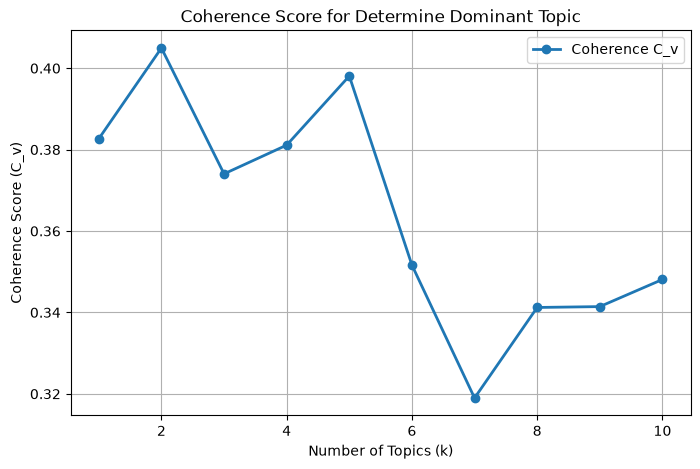

Jumlah Topik = 1 | Coherence Score = 0.3827
Jumlah Topik = 2 | Coherence Score = 0.4050
Jumlah Topik = 3 | Coherence Score = 0.3740
Jumlah Topik = 4 | Coherence Score = 0.3811
Jumlah Topik = 5 | Coherence Score = 0.3981
Jumlah Topik = 6 | Coherence Score = 0.3516
Jumlah Topik = 7 | Coherence Score = 0.3190
Jumlah Topik = 8 | Coherence Score = 0.3412
Jumlah Topik = 9 | Coherence Score = 0.3414
Jumlah Topik = 10 | Coherence Score = 0.3481


In [8]:
coherence_values = []
model_list = []
start_k = CONFIG["COHERENCE_START_K"]
limit_k = CONFIG["COHERENCE_LIMIT_K"]

for num_topics in range(start_k, limit_k + 1):
    model = models.LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=num_topics,
        passes=CONFIG["LDA_PASSES"],
        random_state=CONFIG["RANDOM_SEED"],
    )
    model_list.append(model)
    coherencemodel = CoherenceModel(
        model=model, texts=texts, dictionary=dictionary,
        coherence=CONFIG["COHERENCE_METRIC"], processes=1,
    )
    coherence_values.append(coherencemodel.get_coherence())

x = range(start_k, limit_k + 1)
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(x, coherence_values, marker='o', color='#1f77b4', linewidth=2, label="Coherence C_v")
ax.set_xlabel("Number of Topics (k)")
ax.set_ylabel("Coherence Score (C_v)")
ax.set_title("Coherence Score for Determine Dominant Topic")
ax.legend()
ax.grid(True)
save_figure(fig, "coherence_score_vs_k.png")
plt.show()

for k_val, score in zip(x, coherence_values):
    print(f"Jumlah Topik = {k_val} | Coherence Score = {score:.4f}")


### Kesimpulan Penentuan Jumlah Topik
Berdasarkan hasil analisis **Coherence Score ($C_v$)** di atas:

- Nilai $C_v$ tertinggi menentukan jumlah topik optimal $k^*$ secara **objektif** dan **data-driven**.
- Perlu diperhatikan bahwa nilai $C_v$ yang terus meningkat seiring bertambahnya $k$ tidak selalu berarti topik lebih bermakna secara semantik — bisa terjadi **overfitting** atau topik yang terlalu granular.
- Oleh karena itu, kita memilih $k$ dengan **nilai $C_v$ tertinggi** sekaligus **logis secara interpretasi**, yakni:
  - Jika puncak berada di ujung (k=10), pertimbangkan puncak lokal sebelumnya.
  - Jika ada lonjakan signifikan di suatu titik, titik tersebut diprioritaskan.

Cell berikut secara otomatis memilih jumlah topik optimal dari hasil analisis di atas.


In [9]:
# Memilih jumlah topik optimal secara dinamis dari hasil analisis Coherence Score
optimal_k = start_k + coherence_values.index(max(coherence_values))
optimal_score = max(coherence_values)

print(f"Jumlah topik optimal yang dipilih: k = {optimal_k}")
print(f"Coherence Score (C_v): {optimal_score:.4f}")


Jumlah topik optimal yang dipilih: k = 2
Coherence Score (C_v): 0.4050


### Tabel & Visualisasi k vs Coherence Score (dengan k optimal ditandai)

Versi tabel di bawah memudahkan pelaporan angka pasti di bab Hasil & Pembahasan,
sementara plot beranotasi menandai titik k optimal yang dipilih secara otomatis.

,k,coherence_cv,is_optimal
0,1,0.382668,False
1,2,0.404965,True
2,3,0.374040,False
3,4,0.381102,False
4,5,0.398081,False
5,6,0.351633,False
6,7,0.318975,False
7,8,0.341217,False
8,9,0.341428,False
9,10,0.348092,False


Tabel disimpan: output/tables/coherence_scores_by_k.csv
Figure disimpan: output/figures/coherence_score_optimal_k_annotated.png


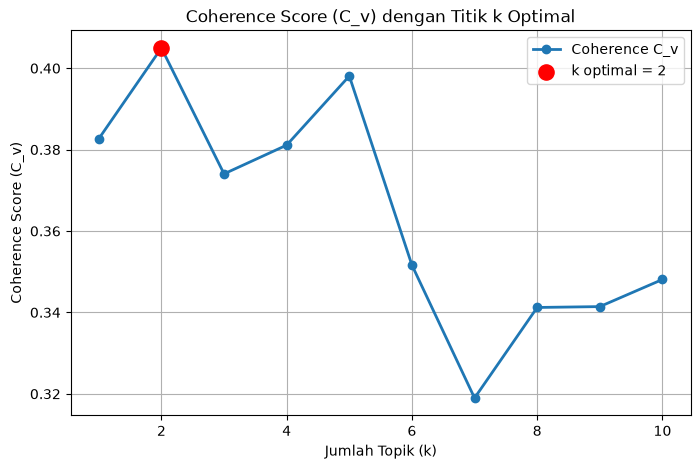

In [10]:
coherence_table = pd.DataFrame({
    "k": list(x),
    "coherence_cv": coherence_values,
})
coherence_table["is_optimal"] = coherence_table["k"] == optimal_k
display(coherence_table)
save_table(coherence_table.set_index("k"), "coherence_scores_by_k.csv")

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(coherence_table["k"], coherence_table["coherence_cv"],
        marker='o', color='#1f77b4', linewidth=2, label="Coherence C_v")
ax.scatter([optimal_k], [optimal_score], color='red', s=120, zorder=5,
           label=f"k optimal = {optimal_k}")
ax.set_xlabel("Jumlah Topik (k)")
ax.set_ylabel("Coherence Score (C_v)")
ax.set_title("Coherence Score (C_v) dengan Titik k Optimal")
ax.legend()
ax.grid(True)
save_figure(fig, "coherence_score_optimal_k_annotated.png")
plt.show()


### 2. Pelatihan Model LDA Final dengan $k$ Optimal

Model LDA dilatih menggunakan jumlah topik yang telah ditentukan secara objektif dari analisis $C_v$ di atas.
Ini adalah tahap **Topic Detection** — yaitu proses menemukan tema-tema tersembunyi dari konten teks tweet.

> **Catatan penting**: Tahap ini murni beroperasi di level **teks/konten**, bukan di level jaringan/pengguna.
> Topic Detection menghasilkan distribusi topik per tweet, yang kemudian digunakan sebagai dasar membangun jaringan pengguna (SNA).


In [11]:
# num_topics diambil dari hasil analisis coherence score (dinamis)
num_topics = optimal_k

lda_model = models.LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=num_topics,
    passes=CONFIG["LDA_PASSES"],
    random_state=CONFIG["RANDOM_SEED"],
)

print(f"LDA Model Topics (k={num_topics}):")
for idx, topic in lda_model.print_topics(-1):
    print(f"Topic {idx}: {topic}")


LDA Model Topics (k=2):
Topic 0: 0.033*"anggaran" + 0.025*"puluhan_ribu" + 0.016*"unit" + 0.012*"yasa_artha" + 0.012*"unit_didistribusikan" + 0.012*"parkir_gudang" + 0.012*"pernyataan_kepala" + 0.012*"tempo_melaporkan" + 0.012*"sorotan_ramai" + 0.012*"wilayah_bogor"
Topic 1: 0.051*"kaos_kaki" + 0.011*"proyek" + 0.011*"indonesia" + 0.011*"kepala" + 0.011*"sulit" + 0.011*"purbaya" + 0.010*"badan_gizi" + 0.010*"harga_pasar" + 0.010*"nasional_sorotan" + 0.010*"mobilitas_petugas"


### Tabel Kata Kunci Topik dengan Bobot

Representasi tabular dari kata kunci tiap topik (kata + bobot probabilitas)
lebih mudah disitasi dan dibandingkan dibanding string mentah dari Gensim.

In [12]:
topic_keyword_rows = []
for topic_id, word_weight_pairs in lda_model.show_topics(num_topics=-1, num_words=10, formatted=False):
    for rank, (word, weight) in enumerate(word_weight_pairs, start=1):
        topic_keyword_rows.append({
            "topic_id": topic_id,
            "rank": rank,
            "word": word,
            "weight": round(weight, 5),
        })

topic_keyword_table = pd.DataFrame(topic_keyword_rows)
display(topic_keyword_table)
save_table(topic_keyword_table.set_index(["topic_id", "rank"]), "topic_keywords_with_weights.csv")


,topic_id,rank,word,weight
0,0,1,anggaran,0.03262
1,0,2,puluhan_ribu,0.02476
2,0,3,unit,0.01637
3,0,4,yasa_artha,0.01241
4,0,5,unit_didistribusikan,0.01198
5,0,6,parkir_gudang,0.01198
6,0,7,pernyataan_kepala,0.01198
7,0,8,tempo_melaporkan,0.01195
8,0,9,sorotan_ramai,0.01195
9,0,10,wilayah_bogor,0.01195


Tabel disimpan: output/tables/topic_keywords_with_weights.csv


### 2a. Interpretasi & Pelabelan Topik Hasil LDA

Setelah model LDA selesai dilatih, setiap topik direpresentasikan sebagai kumpulan kata dengan bobot tertinggi.
Kita perlu menginterpretasikan tiap topik secara **manual** untuk memberikan label yang bermakna.

> **Mengapa penting?** Topik LDA hanyalah distribusi kata — tanpa label, kita tidak bisa mengkomunikasikan
> temuan secara bermakna. Label ini juga digunakan untuk memvalidasi apakah komunitas yang terbentuk
> nantinya sudah sesuai dengan tema yang seharusnya.

Label di bawah ini ditetapkan berdasarkan kata-kata dominan pada masing-masing topik.
Sesuaikan label jika hasil run menghasilkan topik yang berbeda.


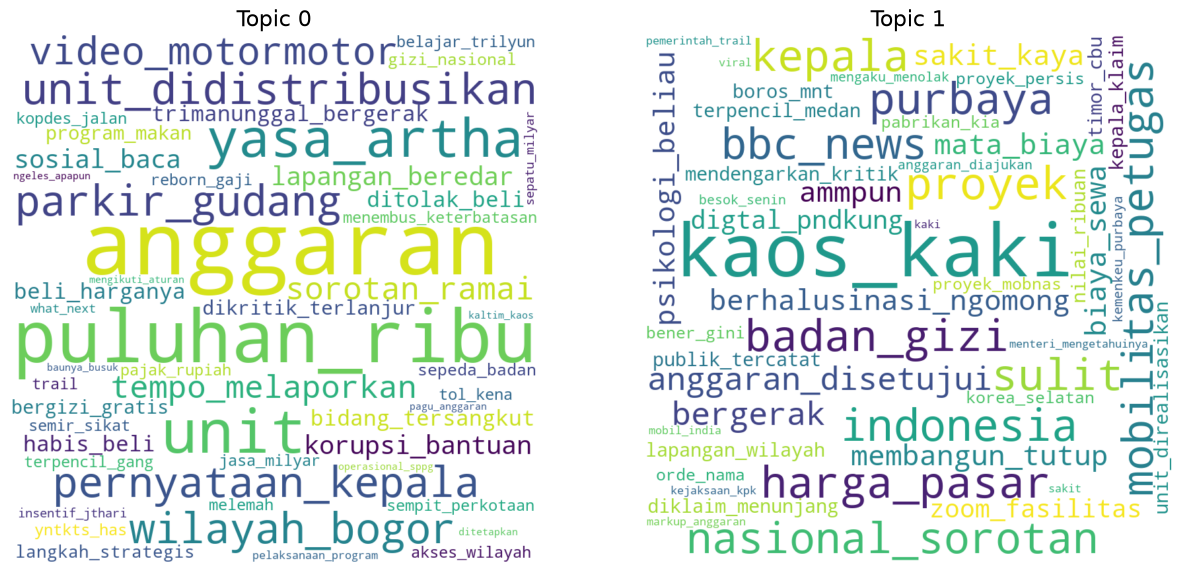

In [13]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, num_topics, figsize=(15, 7), sharex=True, sharey=True)
for i in range(num_topics):
    topic_words = dict(lda_model.show_topic(i, topn=50))
    wordcloud = WordCloud(width=800, height=800, background_color='white').fit_words(topic_words)
    axes[i].imshow(wordcloud, interpolation='bilinear')
    axes[i].axis("off")
    axes[i].set_title(f'Topic {i}', fontsize=16)
plt.show()

In [14]:
# Label topik -- HARUS disesuaikan secara manual dengan hasil run LDA saat ini.
# Format: {topic_id: 'Label Topik'}
# PENTING: update dictionary ini setiap kali k optimal berubah setelah run ulang.
TOPIC_LABELS = {
    0: 'Pengadaan Motor Listrik dan Transparansi Anggaran MBG',
    1: 'Pengadaan Fasilitas Pendukung dan Efisiensi Anggaran MBG',
}

TOPIC_LABELS_EN = {
    0: "Electric Motorcycle Procurement and Budget Transparency in the MBG Program",
    1: "Supporting Facility Procurement and Budget Efficiency in the MBG Program",
}

# Validasi: pastikan setiap topik hasil LDA punya label, agar tidak ada topik
# yang lolos tanpa label saat num_topics berubah (reproducibility safeguard).
missing_labels = [t for t in range(num_topics) if t not in TOPIC_LABELS]
if missing_labels:
    print(f"⚠️  PERINGATAN: topik {missing_labels} belum punya label di TOPIC_LABELS / "
          f"TOPIC_LABELS_EN. Update dictionary di atas sebelum melanjutkan analisis.")

print("=== LABEL TOPIK LDA ===")
print()
for idx, topic in lda_model.print_topics(-1, num_words=10):
    label = TOPIC_LABELS.get(idx, f'Topik {idx}')
    print(f"Topik {idx} -- [{label}]")
    print(f"  Kata kunci: {topic}")
    print()


=== LABEL TOPIK LDA ===

Topik 0 -- [Pengadaan Motor Listrik dan Transparansi Anggaran MBG]
  Kata kunci: 0.033*"anggaran" + 0.025*"puluhan_ribu" + 0.016*"unit" + 0.012*"yasa_artha" + 0.012*"unit_didistribusikan" + 0.012*"parkir_gudang" + 0.012*"pernyataan_kepala" + 0.012*"tempo_melaporkan" + 0.012*"sorotan_ramai" + 0.012*"wilayah_bogor"

Topik 1 -- [Pengadaan Fasilitas Pendukung dan Efisiensi Anggaran MBG]
  Kata kunci: 0.051*"kaos_kaki" + 0.011*"proyek" + 0.011*"indonesia" + 0.011*"kepala" + 0.011*"sulit" + 0.011*"purbaya" + 0.010*"badan_gizi" + 0.010*"harga_pasar" + 0.010*"nasional_sorotan" + 0.010*"mobilitas_petugas"



### Assigning Dominant Topic per Tweet


In [15]:
def get_dominant_topic(topic_distribution):
    """Ambil (topic_id, probability) dengan probabilitas tertinggi dari distribusi
    topik yang SUDAH dihitung -- menghindari pemanggilan get_document_topics dua kali
    untuk dokumen yang sama (sebelumnya dipanggil sekali di loop dan sekali lagi di
    dalam fungsi ini)."""
    return max(topic_distribution, key=lambda x: x[1])

df['dominant_topic_id'] = None
df['dominant_topic_probability'] = None

all_topic_distributions = []
for i, doc_bow in enumerate(corpus):
    topic_dist = lda_model.get_document_topics(doc_bow, minimum_probability=0.0)
    dominant_id, dominant_prob = get_dominant_topic(topic_dist)
    df.loc[i, 'dominant_topic_id'] = dominant_id
    df.loc[i, 'dominant_topic_probability'] = dominant_prob

    for topic_id, prob in topic_dist:
        all_topic_distributions.append({'tweet_index': i, 'topic_id': topic_id, 'probability': prob})

df_tweet_topic_probs = pd.DataFrame(all_topic_distributions)
df_tweet_topic_probs = df_tweet_topic_probs.merge(
    df[['author']].reset_index().rename(columns={'index': 'tweet_index'}),
    on='tweet_index'
)

print("Tweets with dominant topics:")
display(df[['text', 'processed_text', 'dominant_topic_id', 'dominant_topic_probability']].head())


Tweets with dominant topics:


,text,processed_text,dominant_topic_id,dominant_topic_probability
0,"Guys, ada satu angka yang keluar dari riset te...",guys angka riset terbaru celios gue salah fakt...,0,0.996713
1,@tv_inn47694 @menuembegejelek Klo bukan buzzer...,klo buzzer kasih fakta kaum sakit hati ngeriti...,0,0.673216
2,"MBG itu proyek korupsi, memang di dunia lolos ...",proyek korupsi dunia lolos hukuman lihat kelak...,0,0.853183
3,@tempodotco Yg turun ke rakyat brp persen....k...,turun rakyat persenke vendor vendor brpmotor g...,0,0.850198
4,@SeputarTetangga Motor listrik MBG lah,,0,0.5


### Distribusi Topik Dominan & Probabilitasnya

Sebelum melakukan validasi kualitatif, kita lihat dulu sebaran kuantitatif:
berapa tweet yang masuk ke masing-masing topik, dan seberapa "yakin" model
terhadap penugasan topik dominan tersebut (distribusi probabilitas).

Figure disimpan: output/figures/dominant_topic_distribution.png


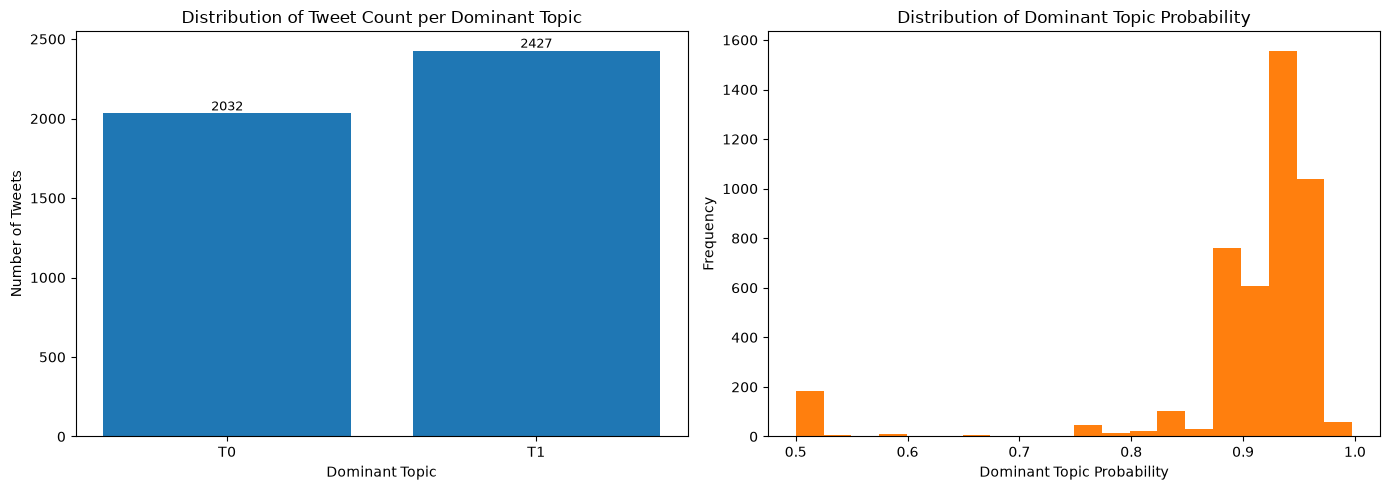

,topic_id,label,n_tweets,share_pct
0,0,Pengadaan Motor Listrik dan Transparansi Angga...,2032,45.57
1,1,Pengadaan Fasilitas Pendukung dan Efisiensi An...,2427,54.43


Tabel disimpan: output/tables/dominant_topic_distribution.csv


In [16]:
topic_counts = df['dominant_topic_id'].dropna().astype(int).value_counts().sort_index()
topic_labels_for_plot = [TOPIC_LABELS.get(t, f"Topik {t}") for t in topic_counts.index]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: jumlah tweet per topik dominan
axes[0].bar(range(len(topic_counts)), topic_counts.values, color='#1f77b4')
axes[0].set_xticks(range(len(topic_counts)))
axes[0].set_xticklabels([f"T{t}" for t in topic_counts.index])
axes[0].set_xlabel("Dominant Topic")
axes[0].set_ylabel("Number of Tweets")
axes[0].set_title("Distribution of Tweet Count per Dominant Topic")
for i, v in enumerate(topic_counts.values):
    axes[0].text(i, v, str(v), ha='center', va='bottom', fontsize=9)

# Panel 2: distribusi probabilitas topik dominan (histogram)
axes[1].hist(df['dominant_topic_probability'].dropna().astype(float), bins=20, color='#ff7f0e')
axes[1].set_xlabel("Dominant Topic Probability")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Distribution of Dominant Topic Probability")

plt.tight_layout()
save_figure(fig, "dominant_topic_distribution.png")
plt.show()

dominant_topic_table = pd.DataFrame({
    "topic_id": topic_counts.index,
    "label": topic_labels_for_plot,
    "n_tweets": topic_counts.values,
    "share_pct": (100 * topic_counts.values / topic_counts.sum()).round(2),
})
display(dominant_topic_table)
save_table(dominant_topic_table.set_index("topic_id"), "dominant_topic_distribution.csv")


### 2b. Validasi Kualitatif — Sampel Tweet per Topik

Untuk memverifikasi bahwa model LDA telah memetakan topik dengan benar,
kita tampilkan beberapa contoh tweet dari masing-masing topik dominan.

Ini adalah **validasi kualitatif**: apakah isi tweet memang sesuai dengan label topik yang kita berikan?


In [17]:
# Tampilkan N_TOPIC_SAMPLES sampel tweet per topik untuk validasi kualitatif
# drop_duplicates per author agar tidak muncul tweet dari user yang sama berulang
N_SAMPLES = CONFIG["N_TOPIC_SAMPLES"]

print("=== SAMPEL TWEET PER TOPIK (Validasi Kualitatif) ===\n")
for topic_id in sorted(df['dominant_topic_id'].dropna().unique()):
    topic_id = int(topic_id)
    label = TOPIC_LABELS.get(topic_id, f'Topik {topic_id}')
    subset = df[df['dominant_topic_id'] == topic_id][['author', 'text', 'dominant_topic_probability']]
    subset = subset.drop_duplicates(subset='author')
    subset = subset.sort_values('dominant_topic_probability', ascending=False).head(N_SAMPLES)

    print(f"{'='*70}")
    print(f"Topik {topic_id} -- {label}")
    print(f"{'='*70}")
    for _, row in subset.iterrows():
        prob = row['dominant_topic_probability']
        author = row['author']
        text_preview = row['text'].replace('\n', ' ')
        print(f"  [@{author}] (prob={prob:.3f})")
        print(f'  "{text_preview}..."')
        print()


=== SAMPEL TWEET PER TOPIK (Validasi Kualitatif) ===

Topik 0 -- Pengadaan Motor Listrik dan Transparansi Anggaran MBG
  [@LambeSahamjja] (prob=0.997)
  "Guys, ada satu angka yang keluar dari riset terbaru Celios yang menurut gue adalah salah satu fakta paling mengejutkan tentang Indonesia yang perlu lo dengar hari ini.  50 orang paling kaya di Indonesia kekayaannya setara dengan kekayaan 55 juta orang Indonesia.  Lima puluh orang.  Lima puluh lima juta orang.  Satu banding satu juta seratus.  Dan tahun sebelumnya angkanya "baru" satu banding satu juta 50 orang terkaya setara 50 juta orang. Artinya dalam satu tahun saja ketimpangan itu tidak menyempit.  Tapi melebar.  Bima Yudhistira dari Celios yang menyampaikan data ini dan konteksnya sangat penting:  Pemerintah selalu membanggakan pertumbuhan ekonomi 5%.  Dan Bima tidak membantah angka itu.  Yang dia pertanyakan adalah kualitasnya.  Pertumbuhan 5% di mana 50 orang semakin kaya sementara 55 juta orang lainnya tidak merasakan dampak n

### 3. Perbedaan Topic Detection dan Community Detection

Dua konsep ini sering tertukar, namun memiliki peran yang sangat berbeda dalam pipeline analisis ini:

| Aspek | **Topic Detection** | **Community Detection** |
|---|---|---|
| **Apa yang dianalisis** | Konten teks (tweet) | Struktur jaringan antar user |
| **Metode** | LDA (Latent Dirichlet Allocation) | Louvain, Greedy Modularity, LPA |
| **Unit analisis** | Dokumen / tweet | Node / pengguna (user) |
| **Output** | Distribusi topik per tweet | Kelompok (komunitas) user |
| **Kapan dilakukan** | **Sebelum** graf dibangun | **Setelah** graf dibangun |
| **Domain ilmu** | NLP / Text Mining | Social Network Analysis (SNA) |

**Alur dalam penelitian ini:**
1. 📄 **Topic Detection (LDA)** → Setiap tweet dipetakan ke distribusi topik
2. 👤 **User-Topic Matrix** → Profil topik setiap pengguna dibangun dari rata-rata distribusi topik tweet mereka
3. 🕸️ **Graf Kesamaan** → Dua user dihubungkan jika cosine similarity profil topik mereka ≥ threshold
4. 🎨 **Community Detection** → Graf diwarnai/dikelompokkan berdasarkan algoritma deteksi komunitas

> Simpelnya: **Topic Detection** menjawab *"Tentang apa tweet ini?"*, sedangkan **Community Detection** menjawab *"Siapa user yang punya ketertarikan serupa?"*


### Membuat Matriks Distribusi Topik Pengguna (User-Topic Matrix)
Mengagregasikan distribusi topik setiap pengguna dari semua tweet mereka menggunakan fungsi rata-rata `.mean()`.


In [18]:
user_topic_agg = df_tweet_topic_probs.groupby(['author', 'topic_id'])['probability'].mean().reset_index()
user_topic_matrix = user_topic_agg.pivot(index='author', columns='topic_id', values='probability').fillna(0)

print("User-Topic Distribution Matrix (head):")
display(user_topic_matrix.head())


User-Topic Distribution Matrix (head):


topic_id,0,1
author,,
0___0cat,0.874433,0.125567
0ceanbloom,0.888530,0.111470
3siji3,0.876806,0.123194
AbdullahYu76015,0.889215,0.110785
AgungYudanto,0.126391,0.873609


### Visualisasi User-Topic Matrix, Top Users per Topik, & Diversity Summary

Tiga output tambahan untuk memperkaya analisis level-pengguna:
1. Heatmap matriks user-topik (sampel user) agar pola keterlibatan topik terlihat visual.
2. Tabel top-N user per topik (siapa yang paling kuat terasosiasi dengan tiap topik).
3. Ringkasan keragaman topik per user menggunakan **Shannon entropy** -- fungsi
   `compute_topic_entropy` ini didefinisikan sekali di sini dan dipakai ulang nanti
   pada tahap deteksi bridge user, supaya logikanya tidak diduplikasi.

Figure disimpan: output/figures/user_topic_matrix_heatmap.png


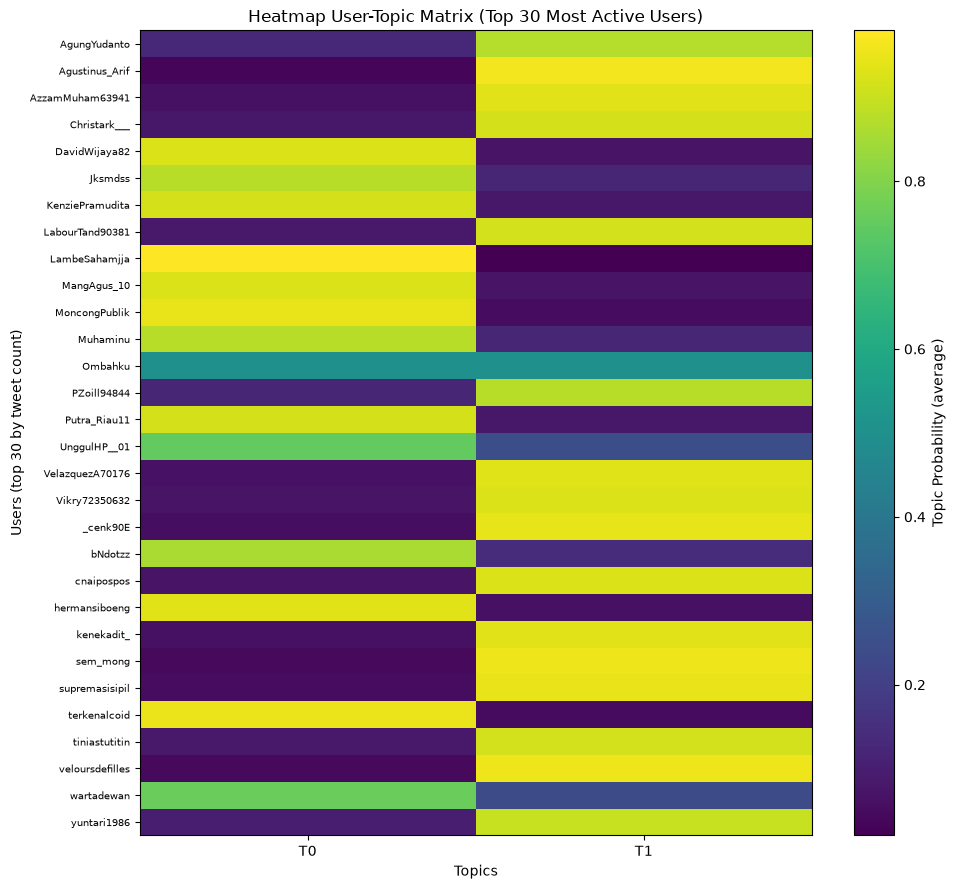

,topic_id,rank,author,probability
0,0,1,deliknewsX,0.9964
1,0,2,suwardi_unisri,0.9950
2,0,3,membacaberitaX,0.9946
3,0,4,masterlopin,0.9945
4,0,5,RagilSemar,0.9935
5,1,1,Agustinus_Arif,0.9615
6,1,2,deniprabowo99,0.9555
7,1,3,veloursdefilles,0.9545
8,1,4,sem_mong,0.9545
9,1,5,MayaHadi89,0.9525


Tabel disimpan: output/tables/top_users_per_topic.csv
Figure disimpan: output/figures/user_topic_entropy_distribution.png


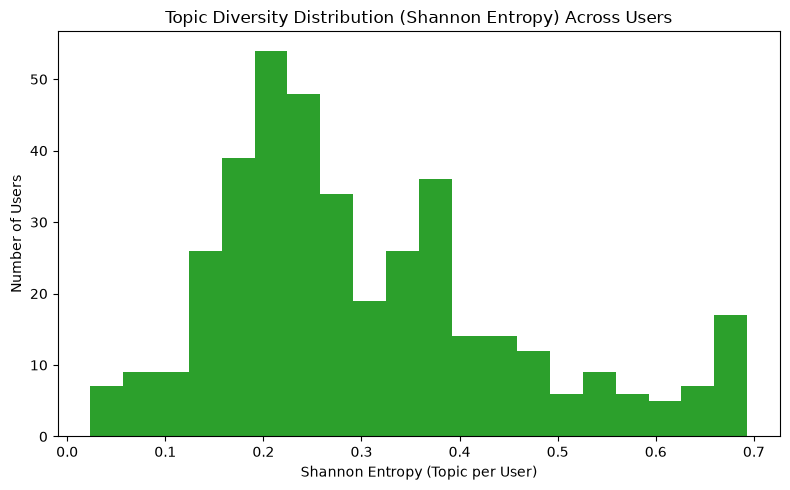

,metric,value
0,mean,0.3047
1,std,0.1530
2,min,0.0237
3,max,0.6931
4,median,0.2592


Tabel disimpan: output/tables/user_topic_entropy_summary.csv


In [19]:
def compute_topic_entropy(matrix, topic_cols):
    """Hitung Shannon entropy dari distribusi topik tiap baris (user).
    +1e-10 ditambahkan untuk menghindari log(0) pada probabilitas nol."""
    return matrix[topic_cols].apply(lambda row: scipy.stats.entropy(row + 1e-10), axis=1)

topic_cols = list(user_topic_matrix.columns)

# 1. Heatmap (sampel user dengan jumlah tweet terbanyak agar representatif & terbaca)
tweet_counts_per_author = df['author'].value_counts()
top_users_for_heatmap = tweet_counts_per_author.head(30).index
heatmap_data = user_topic_matrix.loc[user_topic_matrix.index.intersection(top_users_for_heatmap)]

fig, ax = plt.subplots(figsize=(10, max(6, 0.3 * len(heatmap_data))))
im = ax.imshow(heatmap_data.values, aspect='auto', cmap='viridis')
ax.set_xticks(range(len(topic_cols)))
ax.set_xticklabels([f"T{t}" for t in topic_cols])
ax.set_yticks(range(len(heatmap_data)))
ax.set_yticklabels(heatmap_data.index, fontsize=7)
ax.set_xlabel("Topics")
ax.set_ylabel("Users (top 30 by tweet count)")
ax.set_title("Heatmap User-Topic Matrix (Top 30 Most Active Users)")
fig.colorbar(im, ax=ax, label="Topic Probability (average)")
plt.tight_layout()
save_figure(fig, "user_topic_matrix_heatmap.png")
plt.show()

# 2. Top users per topik
top_n = CONFIG["N_TOP_USERS_PER_TOPIC"]
top_users_rows = []
for t in topic_cols:
    top_users = user_topic_matrix[t].sort_values(ascending=False).head(top_n)
    for rank, (user, prob) in enumerate(top_users.items(), start=1):
        top_users_rows.append({"topic_id": t, "rank": rank, "author": user, "probability": round(prob, 4)})

top_users_table = pd.DataFrame(top_users_rows)
display(top_users_table)
save_table(top_users_table.set_index(["topic_id", "rank"]), "top_users_per_topic.csv")

# 3. Diversity summary (entropy)
entropy_diversity = compute_topic_entropy(user_topic_matrix, topic_cols)

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(entropy_diversity, bins=20, color='#2ca02c')
ax.set_xlabel("Shannon Entropy (Topic per User)")
ax.set_ylabel("Number of Users")
ax.set_title("Topic Diversity Distribution (Shannon Entropy) Across Users")
plt.tight_layout()
save_figure(fig, "user_topic_entropy_distribution.png")
plt.show()

entropy_summary = pd.DataFrame({
    "metric": ["mean", "std", "min", "max", "median"],
    "value": [
        round(entropy_diversity.mean(), 4),
        round(entropy_diversity.std(), 4),
        round(entropy_diversity.min(), 4),
        round(entropy_diversity.max(), 4),
        round(entropy_diversity.median(), 4),
    ],
})
display(entropy_summary)
save_table(entropy_summary.set_index("metric"), "user_topic_entropy_summary.csv")


### Membangun Graf Kesamaan Topik Antar Pengguna


In [20]:
# Simpan user_topic_matrix tanpa kolom entropy (jika ada)
topic_cols = [col for col in user_topic_matrix.columns if col != 'entropy']
user_topic_clean = user_topic_matrix[topic_cols]

user_similarity_matrix = cosine_similarity(user_topic_clean)
user_similarity_df = pd.DataFrame(user_similarity_matrix, index=user_topic_clean.index, columns=user_topic_clean.index)

G_topic = nx.Graph()
G_topic.add_nodes_from(user_similarity_df.index)

similarity_threshold = CONFIG["SIMILARITY_THRESHOLD"]

# Vectorized edge construction: ambil pasangan (i, j) dengan i<j dari upper-triangle
# matriks similarity yang melewati threshold, alih-alih nested Python loop O(n^2)
# yang lambat untuk jumlah user besar.
sim_values = user_similarity_df.values
n_users = sim_values.shape[0]
upper_tri_mask = np.triu(np.ones((n_users, n_users), dtype=bool), k=1)
above_threshold_mask = upper_tri_mask & (sim_values > similarity_threshold)
row_idx, col_idx = np.where(above_threshold_mask)

users_index = user_similarity_df.index
edges = [
    (users_index[i], users_index[j], sim_values[i, j])
    for i, j in zip(row_idx, col_idx)
]
G_topic.add_weighted_edges_from(edges)

# Hapus node terisolasi
isolated_nodes = list(nx.isolates(G_topic))
G_topic.remove_nodes_from(isolated_nodes)

print(f"Jaringan terbentuk dengan {G_topic.number_of_nodes()} node dan {G_topic.number_of_edges()} edge.")


Jaringan terbentuk dengan 397 node dan 49836 edge.


### Statistik Jaringan

Sebelum masuk ke community detection, kita laporkan karakteristik dasar graf
kesamaan topik antar pengguna: jumlah node, jumlah edge, density, rata-rata
degree, dan jumlah connected component.

In [21]:
n_nodes = G_topic.number_of_nodes()
n_edges = G_topic.number_of_edges()
density = nx.density(G_topic)
avg_degree = sum(dict(G_topic.degree()).values()) / n_nodes if n_nodes else float('nan')
connected_components = list(nx.connected_components(G_topic))
n_components = len(connected_components)
largest_component_size = max((len(c) for c in connected_components), default=0)

network_stats = pd.DataFrame({
    "metric": [
        "Jumlah node (user)",
        "Jumlah edge",
        "Network density",
        "Rata-rata degree",
        "Jumlah connected components",
        "Ukuran connected component terbesar",
        "Node terisolasi yang dibuang",
    ],
    "value": [
        n_nodes,
        n_edges,
        round(density, 4),
        round(avg_degree, 2),
        n_components,
        largest_component_size,
        len(isolated_nodes),
    ],
})

display(network_stats)
save_table(network_stats.set_index("metric"), "network_statistics.csv")


,metric,value
0,Jumlah node (user),397.000
1,Jumlah edge,49836.000
2,Network density,0.634
3,Rata-rata degree,251.060
4,Jumlah connected components,1.000
5,Ukuran connected component terbesar,397.000
6,Node terisolasi yang dibuang,0.000


Tabel disimpan: output/tables/network_statistics.csv


### Visualisasi Graf Kesamaan Topik Antar Pengguna

Graf di bawah ini menampilkan jaringan pengguna sebelum dilakukan community detection.
Setiap **node** adalah satu user, dan **edge** menghubungkan dua user yang memiliki
cosine similarity distribusi topik ≥ 0.8. Node yang lebih besar memiliki lebih banyak koneksi (degree tinggi).
Warna node merepresentasikan topik dominan masing-masing user.


Figure disimpan: output/figures/topic_similarity_graph_colorless.png


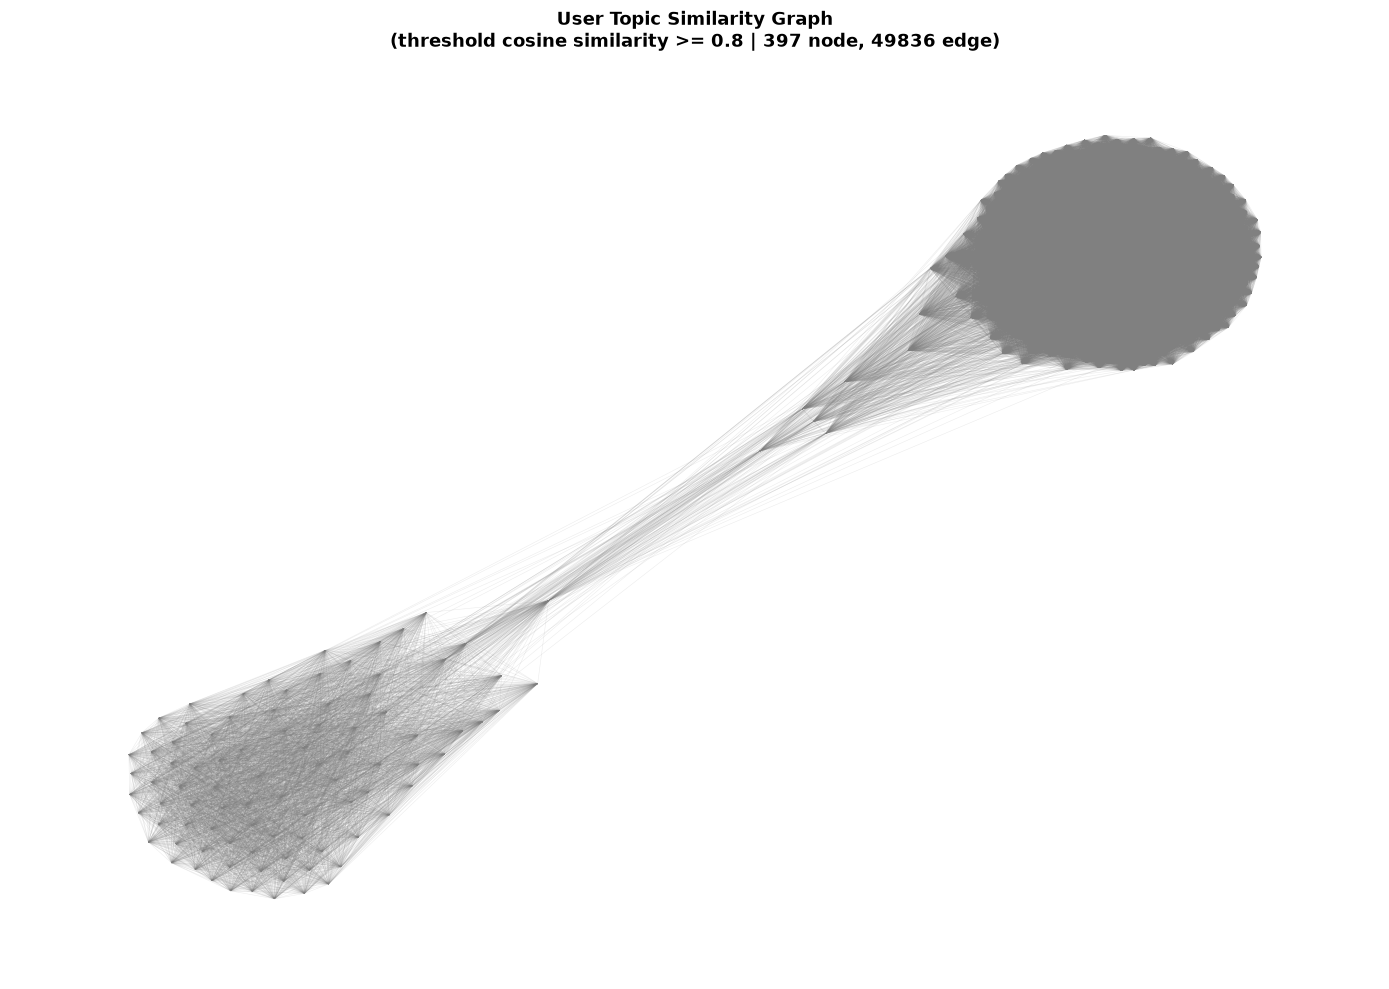

In [22]:
# Visualisasi Graf Kesamaan Topik (sebelum community detection)
fig, ax = plt.subplots(figsize=CONFIG["FIGSIZE_DEFAULT"])

# Layout
pos = nx.spring_layout(G_topic, seed=CONFIG["RANDOM_SEED"], k=0.4)

# Warna node berdasarkan topik dominan user
# Bangun mapping author -> dominant_topic_id dari df
author_topic_map = df.dropna(subset=['author', 'dominant_topic_id']) \
    .groupby('author')['dominant_topic_id'] \
    .agg(lambda x: x.mode()[0]) \
    .astype(int).to_dict()

n_topics = num_topics
cmap_topic = matplotlib.colormaps.get_cmap('tab10').resampled(n_topics)

node_colors = []
node_sizes = []
for node in G_topic.nodes():
    tid = author_topic_map.get(node, 0)
    # node_colors.append(cmap_topic(tid % n_topics))
    node_sizes.append(30 + G_topic.degree(node) * 2)  # ukuran proporsional degree

# Draw
nx.draw_networkx_edges(G_topic, pos, alpha=0.15, width=0.4, edge_color='gray', ax=ax)
nx.draw_networkx_nodes(G_topic, pos, node_color=node_colors, node_size=node_sizes, alpha=0.85, ax=ax)


ax.set_title(
    f"User Topic Similarity Graph\n"
    f"(threshold cosine similarity >= {CONFIG['SIMILARITY_THRESHOLD']} | "
    f"{G_topic.number_of_nodes()} node, {G_topic.number_of_edges()} edge)",
    fontsize=13, fontweight='bold'
)
ax.axis('off')
plt.tight_layout()
save_figure(fig, "topic_similarity_graph_colorless.png")
plt.show()


Figure disimpan: output/figures/topic_similarity_graph.png


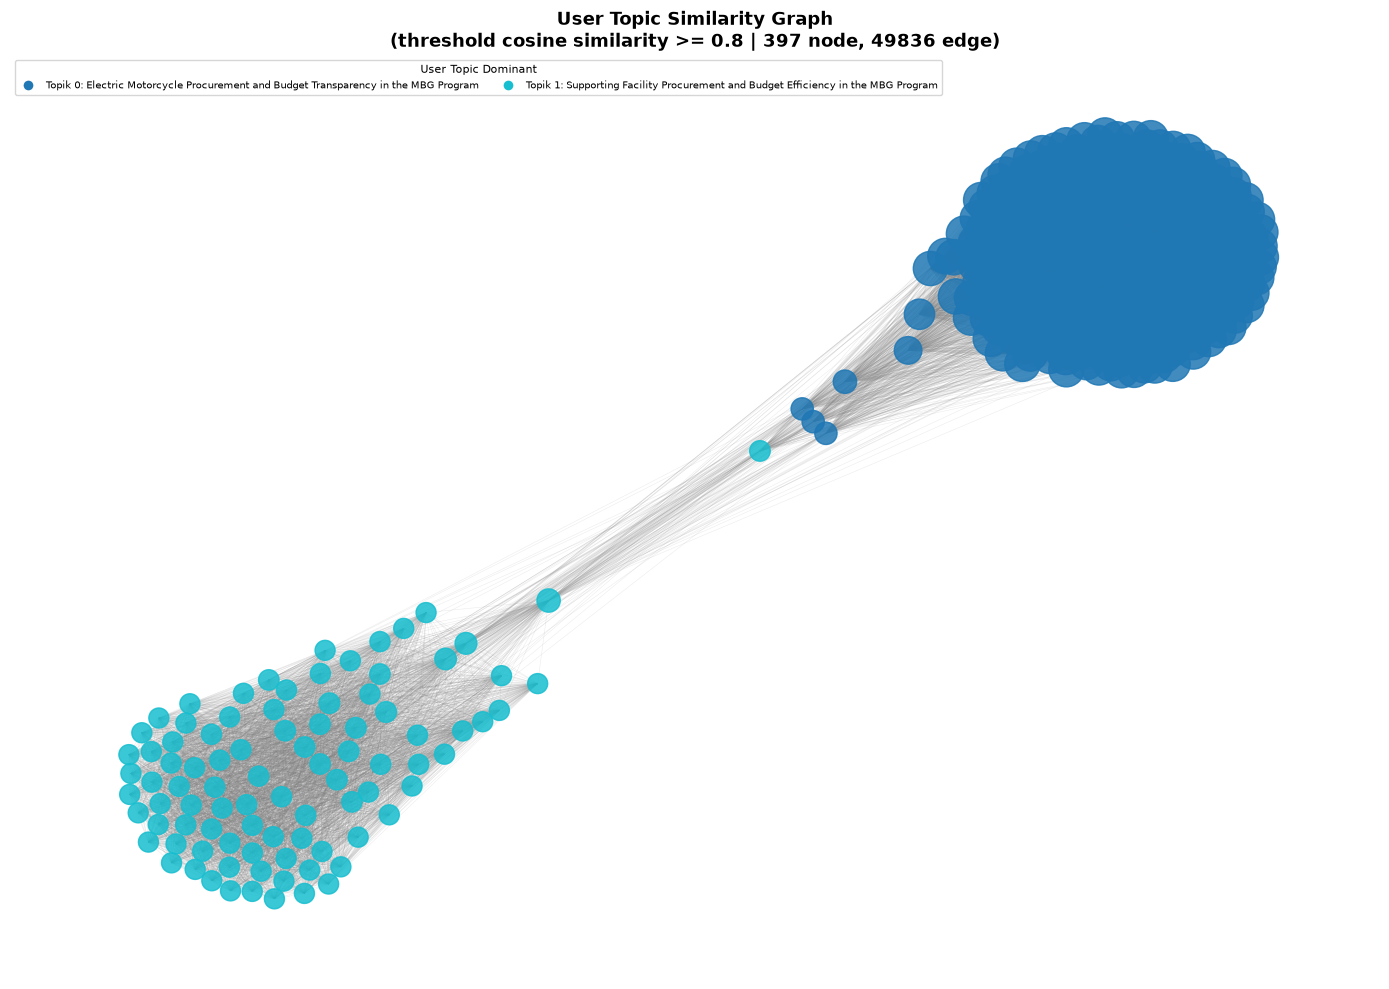

In [23]:
# Visualisasi Graf Kesamaan Topik (sebelum community detection)
fig, ax = plt.subplots(figsize=CONFIG["FIGSIZE_DEFAULT"])

# Layout
pos = nx.spring_layout(G_topic, seed=CONFIG["RANDOM_SEED"], k=0.4)

# Warna node berdasarkan topik dominan user
# Bangun mapping author -> dominant_topic_id dari df
author_topic_map = df.dropna(subset=['author', 'dominant_topic_id']) \
    .groupby('author')['dominant_topic_id'] \
    .agg(lambda x: x.mode()[0]) \
    .astype(int).to_dict()

n_topics = num_topics
cmap_topic = matplotlib.colormaps.get_cmap('tab10').resampled(n_topics)

node_colors = []
node_sizes = []
for node in G_topic.nodes():
    tid = author_topic_map.get(node, 0)
    node_colors.append(cmap_topic(tid % n_topics))
    node_sizes.append(30 + G_topic.degree(node) * 2)  # ukuran proporsional degree

# Draw
nx.draw_networkx_edges(G_topic, pos, alpha=0.15, width=0.4, edge_color='gray', ax=ax)
nx.draw_networkx_nodes(G_topic, pos, node_color=node_colors, node_size=node_sizes, alpha=0.85, ax=ax)

# Legend topik
legend_elements = [
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor=cmap_topic(tid % n_topics), markersize=8,
           label=f'Topik {tid}: {TOPIC_LABELS_EN.get(tid, "")}')
    for tid in range(n_topics)
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=7,
          title='User Topic Dominant', title_fontsize=8,
          framealpha=0.8, ncol=2)

ax.set_title(
    f"User Topic Similarity Graph\n"
    f"(threshold cosine similarity >= {CONFIG['SIMILARITY_THRESHOLD']} | "
    f"{G_topic.number_of_nodes()} node, {G_topic.number_of_edges()} edge)",
    fontsize=13, fontweight='bold'
)
ax.axis('off')
plt.tight_layout()
save_figure(fig, "topic_similarity_graph.png")
plt.show()


### 4. Perbandingan Algoritma Community Detection

Untuk mendeteksi komunitas pengguna secara robust, kita membandingkan **3 algoritma** dengan karakteristik berbeda:

| Algoritma | Pendekatan | Kelebihan | Kekurangan |
|---|---|---|---|
| **Louvain** | Heuristik hierarkis, memaksimalkan modularity secara lokal | Sangat cepat, skalabel untuk graf besar, hasil modularity tinggi | Non-deterministik (ada variasi antar run) |
| **Greedy Modularity (CNM)** | Agglomerative — gabung komunitas yang hasilkan peningkatan modularity terbesar | Deterministik, mudah diinterpretasi | Lebih lambat pada graf besar, cenderung temukan komunitas besar |
| **Label Propagation (LPA)** | Propagasi label secara dinamis sepanjang edge | Sangat cepat, tanpa parameter | Non-deterministik, hasil bisa tidak stabil |

**Alasan pemilihan ketiga algoritma ini:**
- Mewakili 3 paradigma berbeda: *optimasi lokal (Louvain)*, *penggabungan greedy (CNM)*, dan *propagasi label (LPA)*
- Memungkinkan validasi silang: jika ketiga algoritma menghasilkan struktur komunitas serupa, hasilnya lebih dapat dipercaya
- Modularity digunakan sebagai metrik pembanding objektif (semakin tinggi = komunitas semakin terpisah dengan baik)


In [24]:
# 1. Louvain Algorithm
comm_louvain = nx_comm.louvain_communities(G_topic, weight='weight', seed=CONFIG["RANDOM_SEED"])
mod_louvain = nx_comm.modularity(G_topic, comm_louvain, weight='weight')

# 2. Greedy Modularity Algorithm (Clauset-Newman-Moore)
comm_greedy = list(nx_comm.greedy_modularity_communities(G_topic, weight='weight'))
mod_greedy = nx_comm.modularity(G_topic, comm_greedy, weight='weight')

# 3. Label Propagation Algorithm (LPA)
comm_lpa = list(nx_comm.label_propagation_communities(G_topic))
mod_lpa = nx_comm.modularity(G_topic, comm_lpa, weight='weight')

# Simpan mapping node -> community untuk tiap algoritma
louvain_map = {node: i for i, comm in enumerate(comm_louvain) for node in comm}
greedy_map = {node: i for i, comm in enumerate(comm_greedy) for node in comm}
lpa_map = {node: i for i, comm in enumerate(comm_lpa) for node in comm}

def community_size_stats(communities):
    sizes = [len(c) for c in communities]
    return {
        "n_communities": len(communities),
        "mean_size": round(np.mean(sizes), 2) if sizes else 0,
        "median_size": round(np.median(sizes), 2) if sizes else 0,
        "min_size": min(sizes) if sizes else 0,
        "max_size": max(sizes) if sizes else 0,
    }

algorithm_results = {
    "Louvain": (comm_louvain, mod_louvain),
    "Greedy Modularity (CNM)": (comm_greedy, mod_greedy),
    "Label Propagation (LPA)": (comm_lpa, mod_lpa),
}

comparison_rows = []
for algo_name, (communities, modularity_score) in algorithm_results.items():
    stats = community_size_stats(communities)
    comparison_rows.append({
        "algorithm": algo_name,
        "n_communities": stats["n_communities"],
        "modularity": round(modularity_score, 4),
        "mean_size": stats["mean_size"],
        "median_size": stats["median_size"],
        "min_size": stats["min_size"],
        "max_size": stats["max_size"],
    })

community_comparison_table = pd.DataFrame(comparison_rows)
print("===== PERBANDINGAN ALGORITMA KOMUNITAS =====")
display(community_comparison_table)
save_table(community_comparison_table.set_index("algorithm"), "community_detection_comparison.csv")


===== PERBANDINGAN ALGORITMA KOMUNITAS =====


,algorithm,n_communities,modularity,mean_size,median_size,min_size,max_size
0,Louvain,2,0.1502,198.5,198.5,95,302
1,Greedy Modularity (CNM),2,0.1502,198.5,198.5,95,302
2,Label Propagation (LPA),2,0.1489,198.5,198.5,90,307


Tabel disimpan: output/tables/community_detection_comparison.csv


### Visualisasi Perbandingan Komunitas — 3 Algoritma

Setiap warna merepresentasikan satu komunitas yang terdeteksi oleh masing-masing algoritma.


Figure disimpan: output/figures/topic_communities_comparison.png


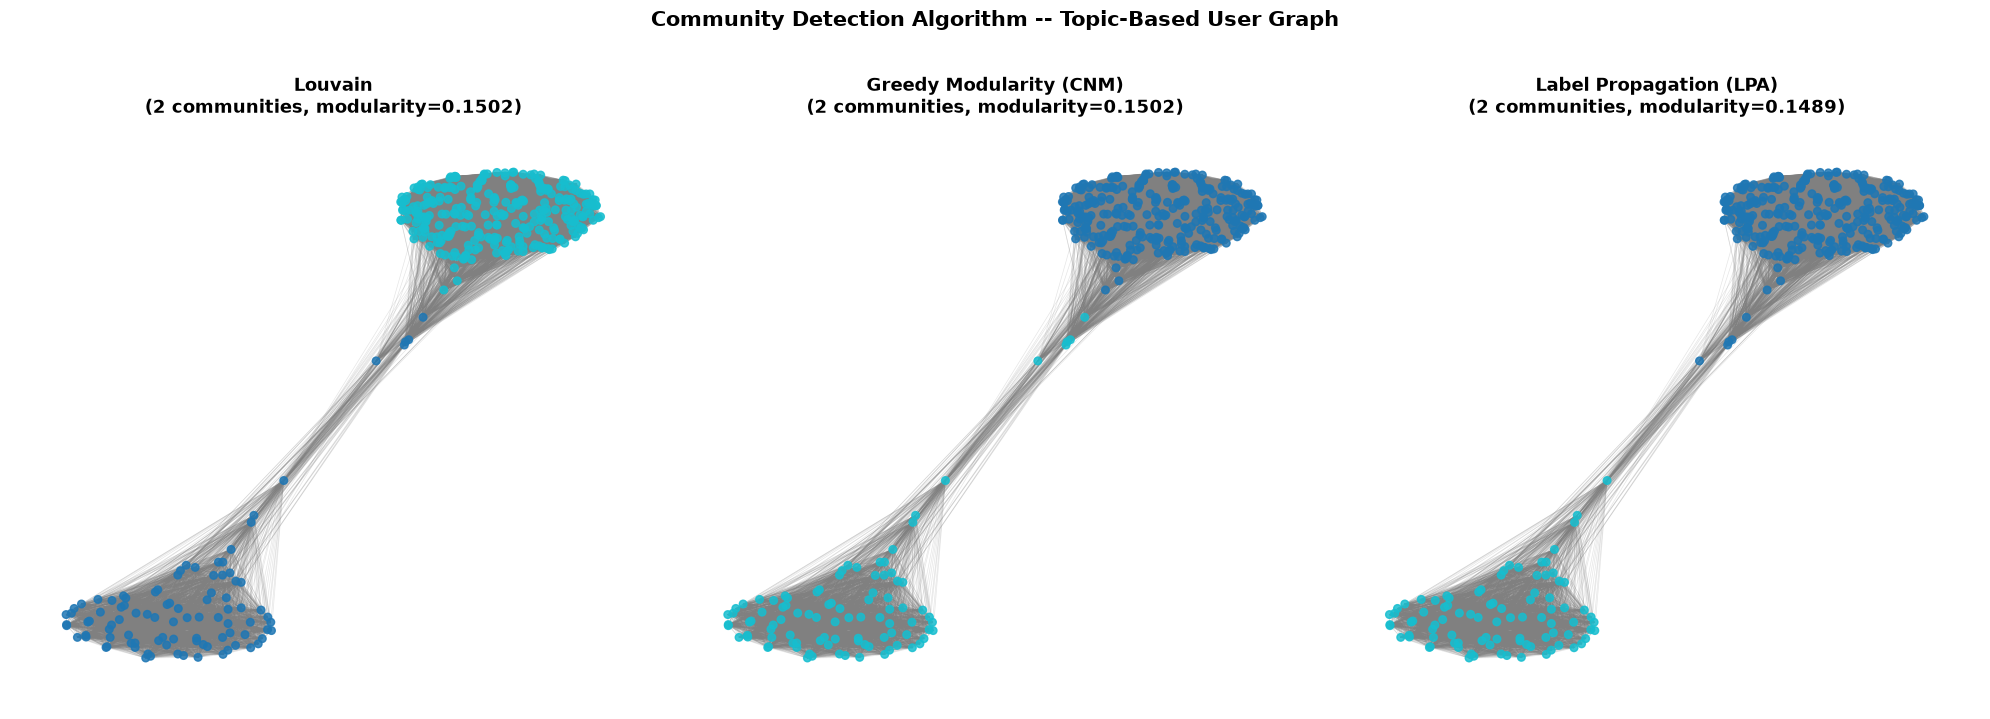

In [25]:
# Layout posisi node (sama untuk ketiga visualisasi agar mudah dibandingkan)
pos = nx.spring_layout(G_topic, seed=CONFIG["RANDOM_SEED"])

def draw_community_graph(G, community_map, title, ax):
    communities = sorted(set(community_map.values()))
    cmap = matplotlib.colormaps.get_cmap('tab10').resampled(len(communities))
    node_colors = [cmap(community_map[node]) for node in G.nodes()]
    nx.draw_networkx_edges(G, pos, alpha=0.2, width=0.5, edge_color='gray', ax=ax)
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=30, alpha=0.85, ax=ax)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.axis('off')

fig, axes = plt.subplots(1, 3, figsize=(20, 7))

draw_community_graph(G_topic, louvain_map,
    f"Louvain\n({len(comm_louvain)} communities, modularity={mod_louvain:.4f})", axes[0])
draw_community_graph(G_topic, greedy_map,
    f"Greedy Modularity (CNM)\n({len(comm_greedy)} communities, modularity={mod_greedy:.4f})", axes[1])
draw_community_graph(G_topic, lpa_map,
    f"Label Propagation (LPA)\n({len(comm_lpa)} communities, modularity={mod_lpa:.4f})", axes[2])

plt.suptitle("Community Detection Algorithm -- Topic-Based User Graph", fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
save_figure(fig, "topic_communities_comparison.png")
plt.show()


### Kesimpulan Perbandingan Algoritma Community Detection

Berdasarkan hasil di atas, kita dapat menarik beberapa kesimpulan:

- **Modularity** digunakan sebagai metrik objektif. Semakin tinggi nilai modularity (mendekati 1.0), semakin baik pemisahan antar komunitas.
- Algoritma dengan modularity tertinggi dipilih sebagai **algoritma utama** untuk analisis lanjutan.
- Perbedaan jumlah komunitas antar algoritma menunjukkan **sensitivitas masing-masing metode** terhadap struktur lokal vs global jaringan.

> Perbandingan ini penting agar hasil community detection **tidak bergantung pada satu algoritma saja** (menghindari bias metodologis).


### Visualisasi Ulang — Graf Komunitas Hasil Louvain

Untuk memperjelas hasil community detection menggunakan algoritma **Louvain**
secara terpisah (tanpa dibandingkan dengan algoritma lain), berikut ditampilkan
ulang graf jaringan user dengan pewarnaan berdasarkan komunitas Louvain,
dilengkapi Note ukuran tiap komunitas.

Figure disimpan: output/figures/topic_communities_louvain_only.png


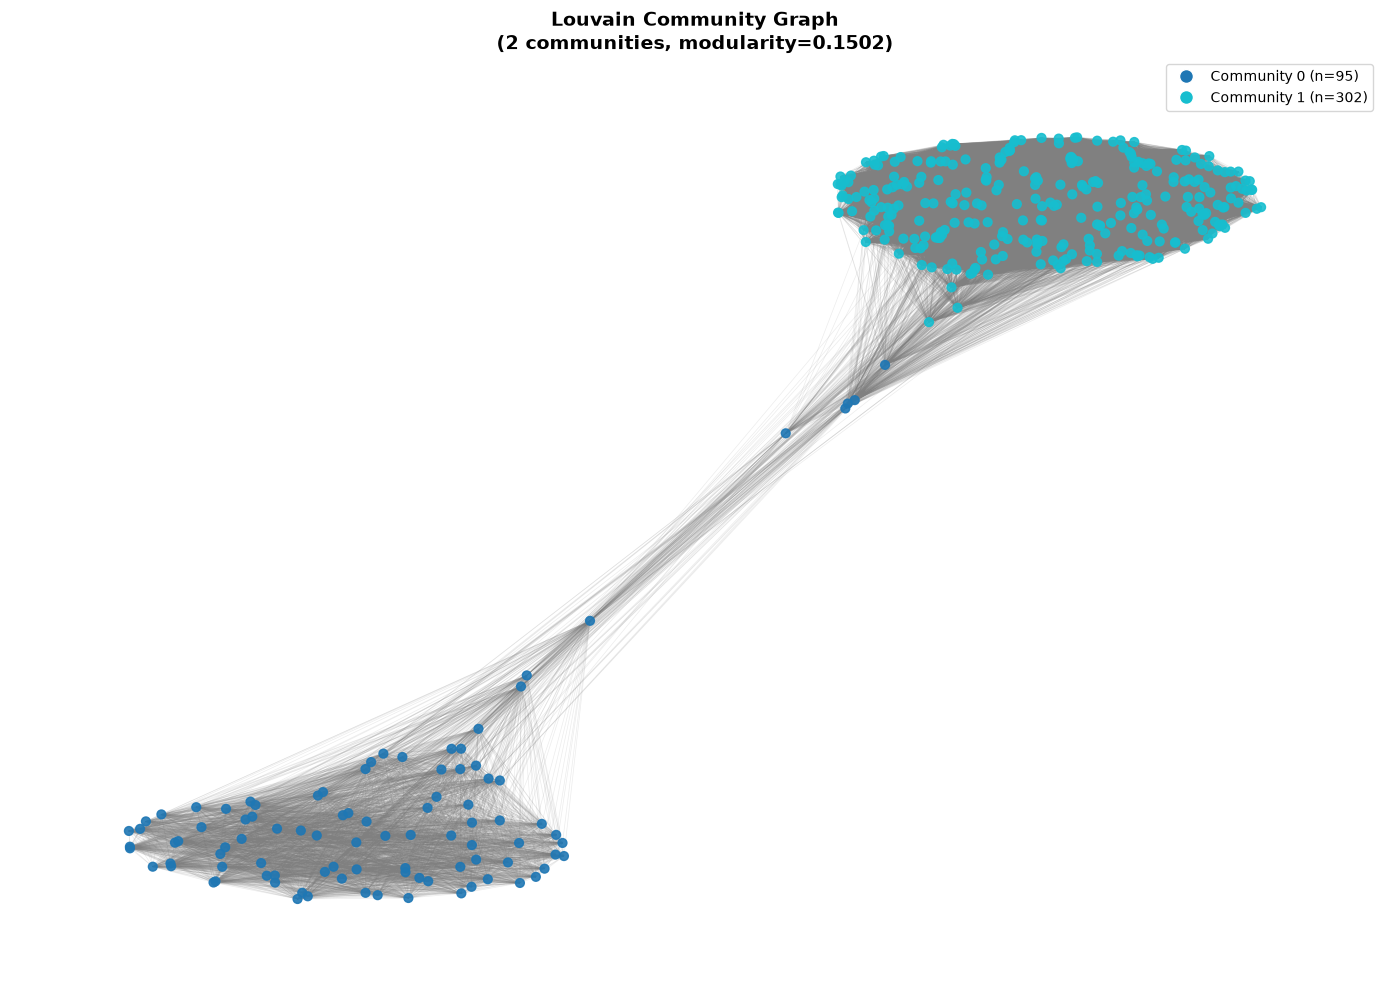

In [26]:
# Visualisasi ulang khusus graf hasil Louvain (standalone, terpisah dari perbandingan 3 algoritma)
fig, ax = plt.subplots(figsize=CONFIG["FIGSIZE_DEFAULT"])

communities_louvain = sorted(set(louvain_map.values()))
cmap = matplotlib.colormaps.get_cmap('tab10').resampled(len(communities_louvain))
node_colors = [cmap(louvain_map[node]) for node in G_topic.nodes()]

nx.draw_networkx_edges(G_topic, pos, alpha=0.15, width=0.5, edge_color='gray', ax=ax)
nx.draw_networkx_nodes(G_topic, pos, node_color=node_colors, node_size=40, alpha=0.9, ax=ax)

# Legend: satu entri per komunitas, lengkap dengan jumlah anggotanya
legend_elements = [
    Line2D(
        [0], [0], marker='o', color='w',
        markerfacecolor=cmap(comm_id), markersize=10,
        label=f"Community {comm_id} (n={len(comm_louvain[comm_id])})"
    )
    for comm_id in communities_louvain
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=10)

ax.set_title(
    f"Louvain Community Graph\n({len(comm_louvain)} communities, modularity={mod_louvain:.4f})",
    fontsize=14, fontweight='bold'
)
ax.axis('off')

plt.tight_layout()
save_figure(fig, "topic_communities_louvain_only.png")
plt.show()

### Visualisasi Graf Louvain — Ukuran Node Proporsional Jumlah Tweet

Graf berikut merupakan visualisasi ulang hasil community detection **Louvain**
dengan dua tambahan informasi visual:

1. **Ukuran node** ∝ jumlah tweet yang ditulis oleh user tersebut —
   semakin besar node, semakin banyak kontribusi tweet user ke dataset.
2. **Warna node** merepresentasikan komunitas Louvain (sama seperti sebelumnya),
   sehingga pola kelompok tetap terlihat.

Kedua encoding visual ini memudahkan identifikasi **user paling aktif** di
setiap komunitas sekaligus mempertahankan struktur komunitas yang terdeteksi.

Figure disimpan: output/figures/louvain_nodesize_tweetcount.png


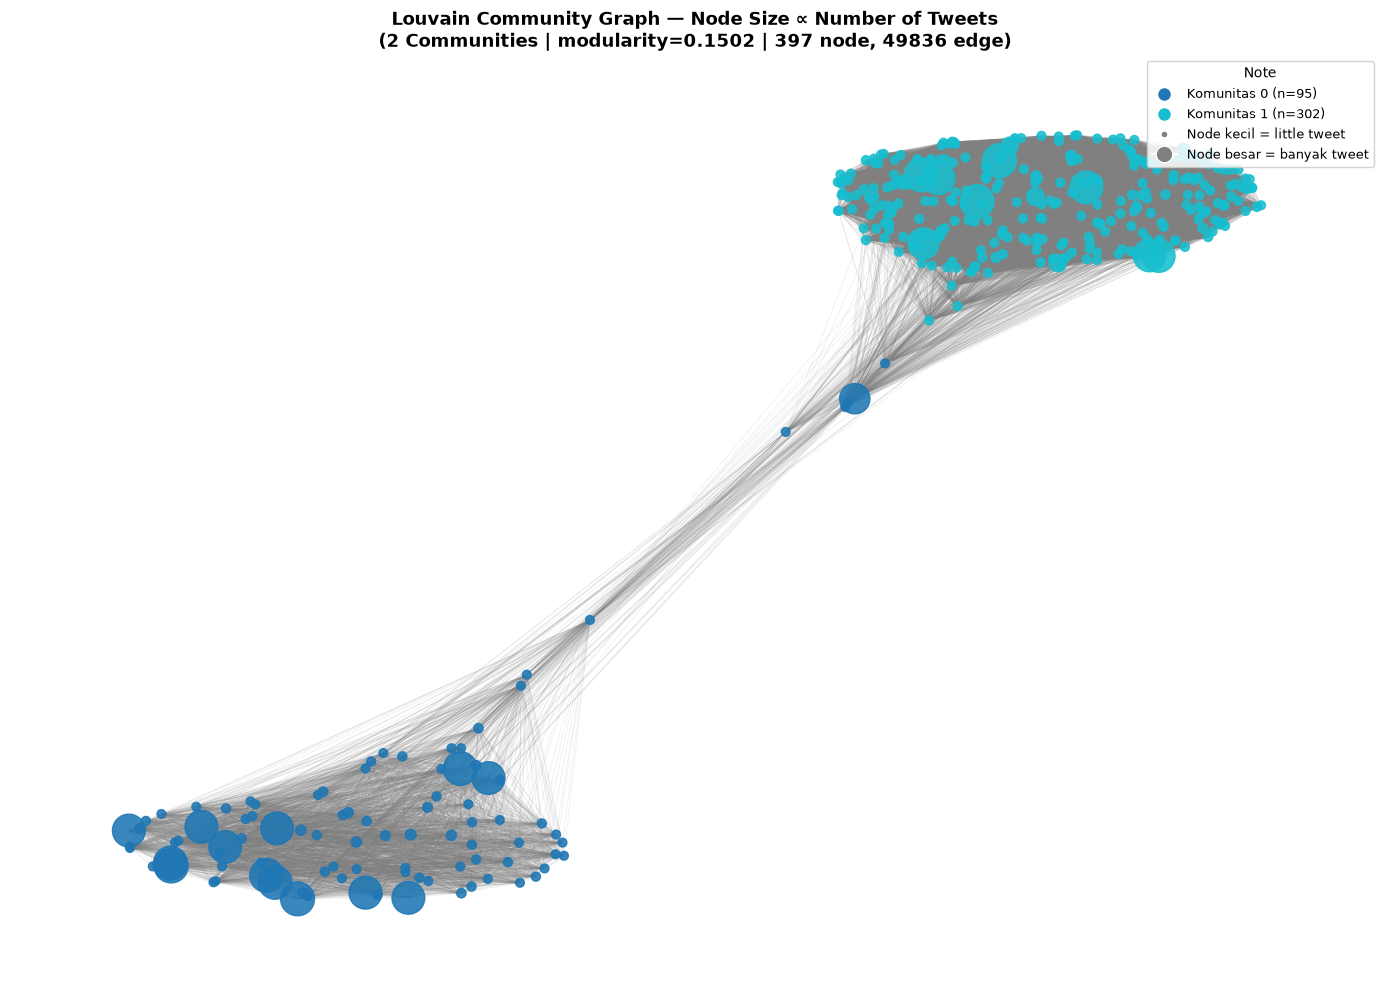

In [27]:
# ── Bangun mapping author → jumlah tweet ────────────────────────────────────
tweet_count_map = df['author'].value_counts().to_dict()

# Tentukan rentang ukuran node yang nyaman secara visual
NODE_MIN_SIZE = 40
NODE_MAX_SIZE = 600

raw_counts = np.array([tweet_count_map.get(node, 1) for node in G_topic.nodes()])
# Normalisasi linear ke [NODE_MIN_SIZE, NODE_MAX_SIZE]
if raw_counts.max() > raw_counts.min():
    node_sizes_tweet = (
        NODE_MIN_SIZE
        + (raw_counts - raw_counts.min())
        / (raw_counts.max() - raw_counts.min())
        * (NODE_MAX_SIZE - NODE_MIN_SIZE)
    ).tolist()
else:
    node_sizes_tweet = [NODE_MIN_SIZE] * len(raw_counts)

# Warna tetap berdasarkan komunitas Louvain
communities_louvain = sorted(set(louvain_map.values()))
cmap_lou = matplotlib.colormaps.get_cmap('tab10').resampled(len(communities_louvain))
node_colors_lou = [cmap_lou(louvain_map[node]) for node in G_topic.nodes()]

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=CONFIG["FIGSIZE_DEFAULT"])

nx.draw_networkx_edges(G_topic, pos, alpha=0.15, width=0.5, edge_color='gray', ax=ax)
nx.draw_networkx_nodes(
    G_topic, pos,
    node_color=node_colors_lou,
    node_size=node_sizes_tweet,
    alpha=0.88,
    ax=ax,
)

# Legend komunitas
legend_elements = [
    Line2D(
        [0], [0], marker='o', color='w',
        markerfacecolor=cmap_lou(comm_id), markersize=10,
        label=f"Komunitas {comm_id} (n={len(comm_louvain[comm_id])})"
    )
    for comm_id in communities_louvain
]
# Tambah entri penjelas ukuran node
legend_elements.append(
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray',
           markersize=5, label='Node kecil = little tweet')
)
legend_elements.append(
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray',
           markersize=12, label='Node besar = banyak tweet')
)

ax.legend(handles=legend_elements, loc='upper right', fontsize=9,
          title='Note', title_fontsize=10, framealpha=0.85)

ax.set_title(
    f"Louvain Community Graph — Node Size ∝ Number of Tweets\n"
    f"({len(comm_louvain)} Communities | modularity={mod_louvain:.4f} | "
    f"{G_topic.number_of_nodes()} node, {G_topic.number_of_edges()} edge)",
    fontsize=13, fontweight='bold'
)
ax.axis('off')
plt.tight_layout()
save_figure(fig, "louvain_nodesize_tweetcount.png")
plt.show()

### Visualisasi Graf Louvain — Warna Node Berdasarkan Topik Dominan

Graf ini memadukan dua lapisan informasi sekaligus:

1. **Warna node** → **topik dominan** user (hasil LDA), bukan komunitas Louvain.
2. **Ukuran node** → jumlah tweet user (sama seperti cell sebelumnya).

Dengan mengganti palet warna dari *komunitas* ke *topik*, kita dapat membandingkan
apakah komunitas yang terbentuk oleh Louvain **sejalan** dengan distribusi topik LDA
— artinya: apakah user satu topik cenderung mengelompok bersama?

Figure disimpan: output/figures/louvain_topic_color_tweetsize.png


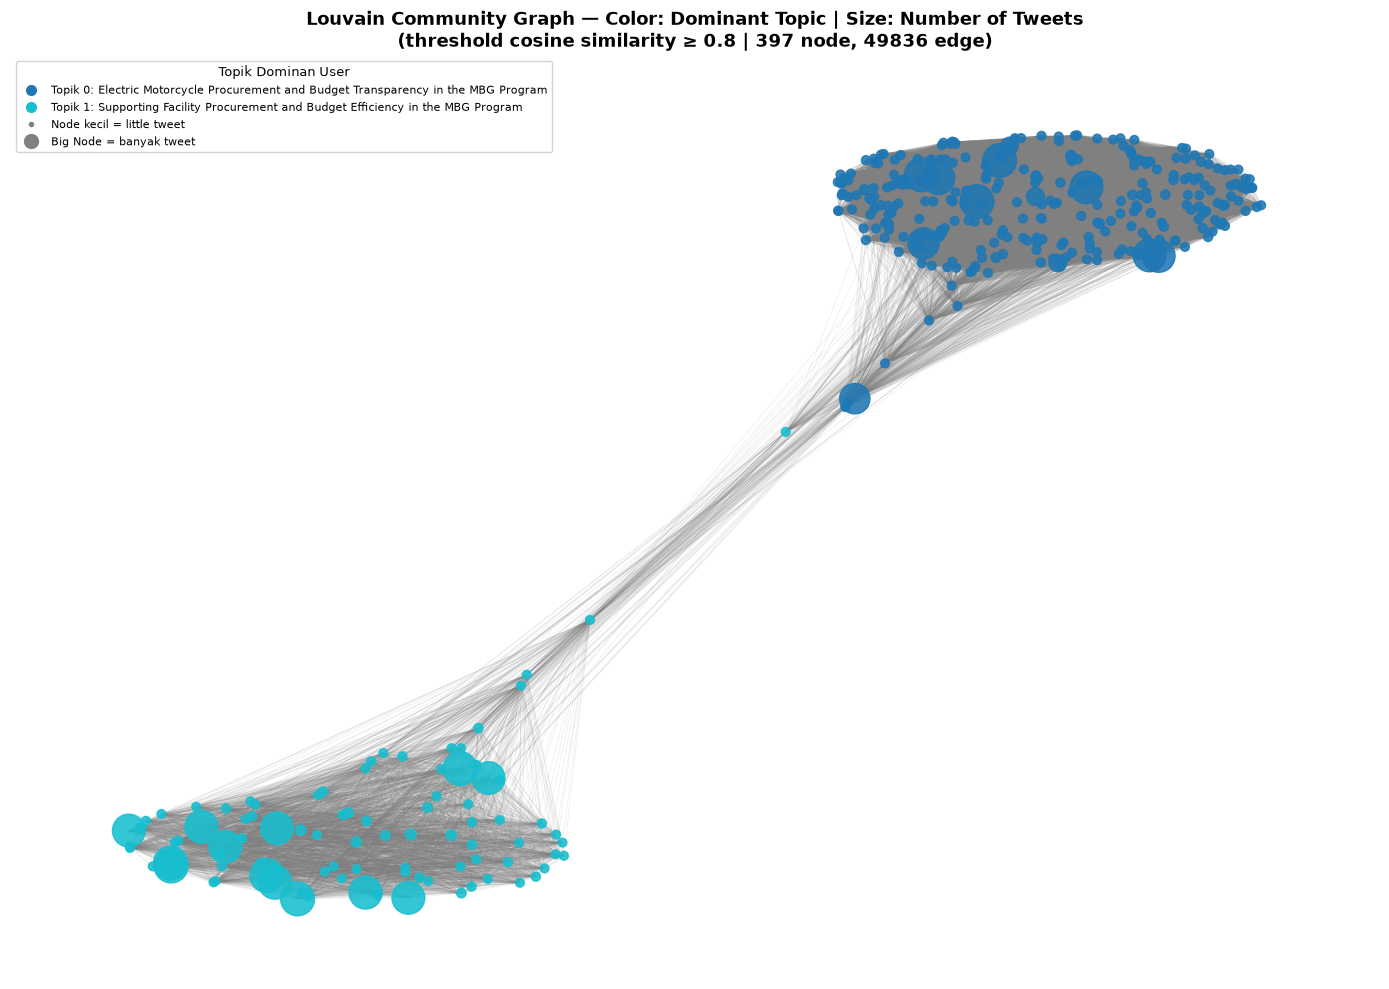

In [28]:
# ── Mapping author → topik dominan (ID integer) ──────────────────────────────
author_topic_map = (
    df.dropna(subset=['author', 'dominant_topic_id'])
    .groupby('author')['dominant_topic_id']
    .agg(lambda x: x.mode()[0])
    .astype(int)
    .to_dict()
)

n_topics = num_topics
cmap_topic = matplotlib.colormaps.get_cmap('tab10').resampled(n_topics)

node_colors_topic = [
    cmap_topic(author_topic_map.get(node, 0) % n_topics)
    for node in G_topic.nodes()
]

# Ukuran node sama: proporsional jumlah tweet (reuse node_sizes_tweet dari cell sebelumnya)
# Jika cell ini dijalankan tersendiri, hitung ulang:
if 'node_sizes_tweet' not in dir():
    tweet_count_map = df['author'].value_counts().to_dict()
    NODE_MIN_SIZE, NODE_MAX_SIZE = 40, 600
    raw_counts = np.array([tweet_count_map.get(node, 1) for node in G_topic.nodes()])
    if raw_counts.max() > raw_counts.min():
        node_sizes_tweet = (
            NODE_MIN_SIZE
            + (raw_counts - raw_counts.min())
            / (raw_counts.max() - raw_counts.min())
            * (NODE_MAX_SIZE - NODE_MIN_SIZE)
        ).tolist()
    else:
        node_sizes_tweet = [NODE_MIN_SIZE] * len(raw_counts)

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=CONFIG["FIGSIZE_DEFAULT"])

nx.draw_networkx_edges(G_topic, pos, alpha=0.15, width=0.5, edge_color='gray', ax=ax)
nx.draw_networkx_nodes(
    G_topic, pos,
    node_color=node_colors_topic,
    node_size=node_sizes_tweet,
    alpha=0.88,
    ax=ax,
)

# Legend topik
legend_topic = [
    Line2D(
        [0], [0], marker='o', color='w',
        markerfacecolor=cmap_topic(tid % n_topics), markersize=9,
        label=f"Topik {tid}: {TOPIC_LABELS_EN.get(tid, f'Topic {tid}')}"
    )
    for tid in range(n_topics)
]
# Tambah penjelas ukuran
legend_topic += [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray',
           markersize=5,  label='Node kecil = little tweet'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray',
           markersize=12, label='Big Node = banyak tweet'),
]

ax.legend(handles=legend_topic, loc='upper left', fontsize=8,
          title='Topik Dominan User', title_fontsize=9,
          framealpha=0.85, ncol=1)

ax.set_title(
    f"Louvain Community Graph — Color: Dominant Topic | Size: Number of Tweets\n"
    f"(threshold cosine similarity ≥ {CONFIG['SIMILARITY_THRESHOLD']} | "
    f"{G_topic.number_of_nodes()} node, {G_topic.number_of_edges()} edge)",
    fontsize=13, fontweight='bold'
)
ax.axis('off')
plt.tight_layout()
save_figure(fig, "louvain_topic_color_tweetsize.png")
plt.show()

### 5. Deteksi User yang Overlap Komunitas (Bridge Users)

**Apa itu user yang "overlap"?**

Dalam jaringan komunitas, *overlap* terjadi ketika seorang user memiliki distribusi ketertarikan topik yang **tersebar merata ke banyak topik**, bukan terkonsentrasi pada satu topik dominan. User seperti ini berperan sebagai **jembatan (bridge)** antar komunitas — mereka bisa relevan di banyak kelompok sekaligus.

**Metode deteksi:**  
Kita menggunakan **Shannon Entropy** dari profil distribusi topik setiap user:
- Entropy **tinggi** → distribusi merata → user berpotensi overlap banyak komunitas
- Entropy **rendah** → distribusi terpusat → user dominan di satu topik/komunitas

> Ini menjawab pertanyaan: *"Apakah ada user yang bisa masuk ke lebih dari satu komunitas?"* — Jawabannya: ya, mereka adalah user dengan entropy tinggi.


In [29]:
# Hitung entropy distribusi topik per user, memakai fungsi compute_topic_entropy
# yang sudah didefinisikan di tahap User-Topic Matrix (hindari duplikasi logika).
topic_cols_only = [col for col in user_topic_matrix.columns if col != 'entropy']
user_topic_matrix['entropy'] = compute_topic_entropy(user_topic_matrix, topic_cols_only)

top_overlap = user_topic_matrix.sort_values(by='entropy', ascending=False)[['entropy']].head(10)
print("10 User Paling Overlap (Bridge Users -- tersebar di banyak topik):")
display(top_overlap)

# Threshold: user dengan entropy > mean + k*std dianggap overlap (k dari CONFIG)
entropy_mean = user_topic_matrix['entropy'].mean()
entropy_std = user_topic_matrix['entropy'].std()
threshold_entropy = entropy_mean + CONFIG["BRIDGE_ENTROPY_STD_MULTIPLIER"] * entropy_std

bridge_users = user_topic_matrix[user_topic_matrix['entropy'] > threshold_entropy].index.tolist()
print(f"\nJumlah Bridge Users (entropy > {threshold_entropy:.4f}): {len(bridge_users)}")

bridge_users_table = user_topic_matrix.loc[bridge_users, ['entropy']].sort_values('entropy', ascending=False)
bridge_users_table.index.name = "author"
save_table(bridge_users_table, "bridge_users.csv")


10 User Paling Overlap (Bridge Users -- tersebar di banyak topik):


topic_id,entropy
author,
Ombahku,0.693147
Argadhahana,0.693147
normansihite,0.693147
beulangong174,0.692988
TirtoID,0.692849
Kastam67,0.690460
ainanoteu,0.688852
ddycw,0.686276
LangkahSantai,0.682043



Jumlah Bridge Users (entropy > 0.4577): 62
Tabel disimpan: output/tables/bridge_users.csv


### Visualisasi Bridge Users pada Jaringan


Figure disimpan: output/figures/louvain_bridge_topic_tweetsize.png


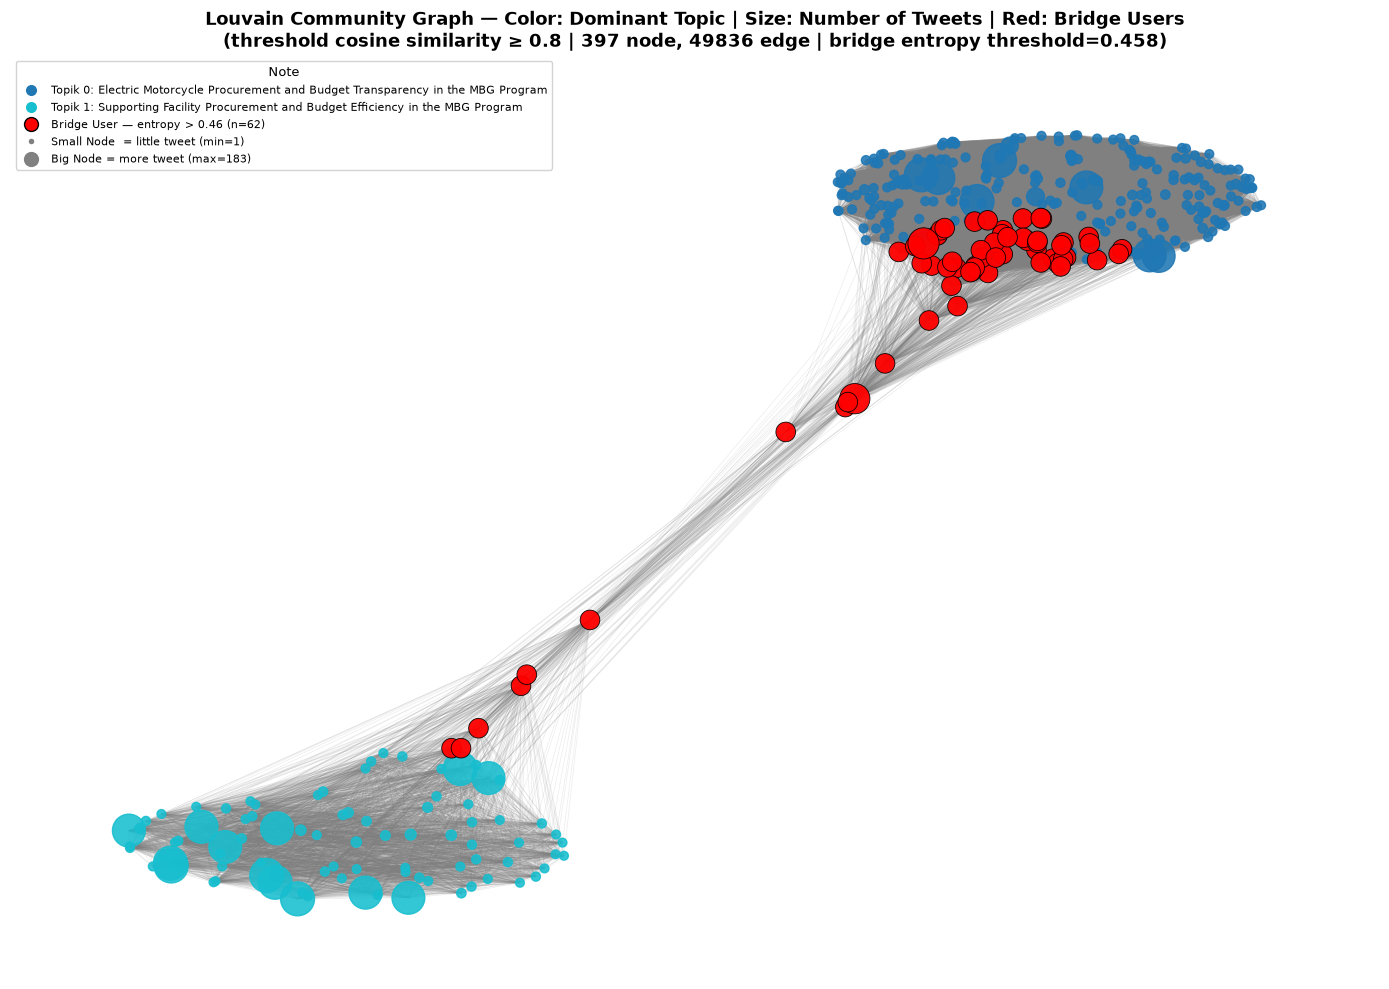

In [30]:
# Visualisasi Bridge Users — overlay di atas graf topik dominan + ukuran tweet
fig, ax = plt.subplots(figsize=CONFIG["FIGSIZE_DEFAULT"])

# Pisahkan node biasa vs bridge user
regular_nodes = [n for n in G_topic.nodes() if n not in bridge_users]
bridge_nodes  = [n for n in G_topic.nodes() if n in bridge_users]

# Warna & ukuran node biasa (topik dominan + jumlah tweet)
regular_colors = [cmap_topic(author_topic_map.get(n, 0) % n_topics) for n in regular_nodes]
regular_sizes  = [node_sizes_tweet[list(G_topic.nodes()).index(n)] for n in regular_nodes]

# Ukuran bridge nodes (ikut skala tweet, minimal 200 agar tetap menonjol)
bridge_sizes = [
    max(node_sizes_tweet[list(G_topic.nodes()).index(n)], 200)
    for n in bridge_nodes
]

nx.draw_networkx_edges(G_topic, pos, alpha=0.15, width=0.5, edge_color='gray', ax=ax)

# Node biasa
nx.draw_networkx_nodes(
    G_topic, pos,
    nodelist=regular_nodes,
    node_color=regular_colors,
    node_size=regular_sizes,
    alpha=0.88,
    ax=ax,
)

# Bridge users — merah, outline hitam
nx.draw_networkx_nodes(
    G_topic, pos,
    nodelist=bridge_nodes,
    node_color='red',
    node_size=bridge_sizes,
    edgecolors='black',
    linewidths=0.6,
    alpha=0.95,
    ax=ax,
)

# Legend
legend_elements = [
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor=cmap_topic(tid % n_topics), markersize=9,
           label=f"Topik {tid}: {TOPIC_LABELS_EN.get(tid, f'Topic {tid}')}")
    for tid in range(n_topics)
]
legend_elements += [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='red',
           markeredgecolor='black', markersize=10,
           label=f"Bridge User — entropy > {threshold_entropy:.2f} (n={len(bridge_nodes)})"),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray',
           markersize=5,  label=f"Small Node  = little tweet (min={int(raw_counts.min())})"),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray',
           markersize=12, label=f"Big Node = more tweet (max={int(raw_counts.max())})"),
]

ax.legend(handles=legend_elements, loc='upper left', fontsize=8,
          title='Note', title_fontsize=9,
          framealpha=0.85, ncol=1)

ax.set_title(
    f"Louvain Community Graph — Color: Dominant Topic | Size: Number of Tweets | Red: Bridge Users\n"
    f"(threshold cosine similarity ≥ {CONFIG['SIMILARITY_THRESHOLD']} | "
    f"{G_topic.number_of_nodes()} node, {G_topic.number_of_edges()} edge | "
    f"bridge entropy threshold={threshold_entropy:.3f})",
    fontsize=13, fontweight='bold'
)
ax.axis('off')
plt.tight_layout()
save_figure(fig, "louvain_bridge_topic_tweetsize.png")
plt.show()

### 6. Validasi Kualitatif — Sampel Tweet per Komunitas

Setelah komunitas terdeteksi, kita ambil sampel tweet dari user di tiap komunitas
untuk memverifikasi apakah **pengelompokan komunitas sudah sesuai** dengan topik yang dominan.

Ini menjawab pertanyaan: *"Apakah user dalam satu komunitas memang membicarakan hal yang sama?"*

Kita menggunakan hasil **algoritma Louvain** (modularity tertinggi) sebagai dasar validasi.


In [31]:
# Mapping author -> community (Louvain)
df_community = pd.DataFrame([
    {'author': node, 'community_id': louvain_map[node]}
    for node in G_topic.nodes()
])

# Gabungkan dengan dataframe tweet
df_with_comm = df.merge(df_community, on='author', how='inner')
df_with_comm['dominant_topic_id'] = df_with_comm['dominant_topic_id'].astype('Int64')

N_COMM_SAMPLES = CONFIG["N_COMMUNITY_SAMPLES"]

print("=== SAMPEL TWEET PER KOMUNITAS (Validasi Kualitatif) ===")
print("Algoritma: Louvain Community Detection\n")

community_summary_rows = []
for comm_id in sorted(df_with_comm['community_id'].unique()):
    comm_members = df_with_comm[df_with_comm['community_id'] == comm_id]

    # Topik dominan di komunitas ini
    top_topic = comm_members['dominant_topic_id'].mode()
    top_topic_id = int(top_topic.iloc[0]) if len(top_topic) > 0 else -1
    top_topic_label = TOPIC_LABELS.get(top_topic_id, '?')
    n_users = comm_members['author'].nunique()

    print(f"{'='*70}")
    print(f"Komunitas {comm_id} | {n_users} user | Topik Dominan: Topik {top_topic_id} -- {top_topic_label}")
    print(f"{'='*70}")

    # Distribusi topik dalam komunitas
    topic_dist = comm_members['dominant_topic_id'].value_counts().head(3)
    for tid, cnt in topic_dist.items():
        lbl = TOPIC_LABELS.get(int(tid), '?')
        print(f"  Topik {tid} ({lbl}): {cnt} tweet")
    print()

    # Sampel tweet
    samples = comm_members[['author','text','dominant_topic_id']].drop_duplicates(subset='author').head(N_COMM_SAMPLES)
    sample_texts = []
    for _, row in samples.iterrows():
        tid = int(row['dominant_topic_id']) if pd.notna(row['dominant_topic_id']) else -1
        lbl = TOPIC_LABELS.get(tid, '?')
        text_preview = str(row['text'])[:180].replace('\n', ' ')
        print(f"  [@{row['author']}] Topik {tid} -- {lbl}")
        print(f'  "{text_preview}..."')
        print()
        sample_texts.append(f"@{row['author']}: {text_preview}")

    representative_users = comm_members.sort_values('dominant_topic_probability', ascending=False) \
        .drop_duplicates(subset='author')['author'].head(N_COMM_SAMPLES).tolist()

    community_summary_rows.append({
        "community_id": comm_id,
        "n_users": n_users,
        "dominant_topic_id": top_topic_id,
        "dominant_topic_label": top_topic_label,
        "representative_users": ", ".join(representative_users),
        "sample_tweets": " | ".join(sample_texts),
    })

community_summary_table = pd.DataFrame(community_summary_rows)
save_table(community_summary_table.set_index("community_id"), "community_interpretation_summary.csv")


=== SAMPEL TWEET PER KOMUNITAS (Validasi Kualitatif) ===
Algoritma: Louvain Community Detection

Komunitas 0 | 95 user | Topik Dominan: Topik 1 -- Pengadaan Fasilitas Pendukung dan Efisiensi Anggaran MBG
  Topik 1 (Pengadaan Fasilitas Pendukung dan Efisiensi Anggaran MBG): 2427 tweet
  Topik 0 (Pengadaan Motor Listrik dan Transparansi Anggaran MBG): 147 tweet

  [@normansihite] Topik 0 -- Pengadaan Motor Listrik dan Transparansi Anggaran MBG
  "@SeputarTetangga Motor listrik MBG lah..."

  [@Christark___] Topik 1 -- Pengadaan Fasilitas Pendukung dan Efisiensi Anggaran MBG
  "@OG_Whip @ryenyuku @svnwcloudie @iPopBase Program MBG maksudmu? Yg pake ada proyek pengadaan kaos kaki, motor listrik merk goib itu? Atau pengadaan anggaran absensi itu jg?..."

  [@Vikry72350632] Topik 1 -- Pengadaan Fasilitas Pendukung dan Efisiensi Anggaran MBG
  "@zalkad @Metro_TV Apa pengalihan isu motor listrik mbg dan kaos kaki mbg pengadaan motor listrik dan mobil dari India yang lagi jadi sonotan tiba-tiba

## Kesimpulan

### Catatan Konteks Dataset

Dataset penelitian ini dikumpulkan menggunakan kata kunci yang sudah spesifik
mengarah ke isu motor listrik dalam program MBG — *"Motor Listrik MBG"*,
*"Pengadaan Motor Listrik MBG"*, dan tagar *#MotorMBG*. Seluruh tweet dalam
dataset sejak awal sudah terfilter pada satu sub-isu tertentu, bukan
merepresentasikan keseluruhan wacana publik tentang program MBG secara umum.
Konteks ini penting untuk memaknai temuan-temuan di bawah secara tepat.

### Topic Detection (LDA)

Analisis coherence score (C_v) menghasilkan jumlah topik optimal **k = 2**
dengan C_v = 0,405 — berada di kisaran sedang, mengindikasikan separasi topik
yang cukup jelas namun tidak sangat tajam. Kedua topik yang terbentuk adalah:

- **Topik 0 — Pengadaan Motor Listrik dan Transparansi Anggaran MBG**
  (45,57% | 2.032 tweet)
- **Topik 1 — Pengadaan Fasilitas Pendukung dan Efisiensi Anggaran MBG**
  (54,43% | 2.427 tweet)

Kedua topik tidak benar-benar terpisah secara tematik murni. Topik 0
didominasi entitas spesifik ("yasa_artha", "parkir_gudang") yang merujuk
pada aktor dan lokasi pengadaan, sementara Topik 1 menampilkan token seperti
"kaos_kaki" sebagai bobot tertinggi yang mengindikasikan framing kritik
terhadap kewajaran barang yang diadakan. Dengan demikian, keduanya lebih
merepresentasikan **dua framing dari satu isu yang sama** — kontroversi
pengadaan motor listrik dan anggaran terkaitnya dalam program MBG — daripada
dua tema yang benar-benar berbeda.

Rendahnya keragaman topik (k=2 dengan coherence moderat) konsisten dengan
sifat dataset yang sudah terfilter sejak proses scraping, bukan semata-mata
mencerminkan sedikitnya keragaman wacana MBG secara luas. Label topik
merupakan hasil interpretasi manual peneliti terhadap distribusi kata,
bukan keluaran otomatis model.

### Social Network Analysis

Graf kesamaan topik antar pengguna terdiri dari **397 node (user)** dan
**49.836 edge** dengan network density **0,634** — sangat tinggi untuk graf
sosial pada umumnya. Density tinggi ini konsisten dengan dua faktor:
(1) hanya terdapat 2 topik yang relatif general sehingga profil topik antar
pengguna cenderung mirip satu sama lain, dan (2) dataset secara inherent
homogen akibat strategi scraping berbasis keyword spesifik, sehingga seluruh
user dalam jaringan dijamin membicarakan isu yang berkaitan.

Ketiga algoritma community detection — Louvain, Greedy Modularity (CNM), dan
Label Propagation — secara **konsisten menghasilkan 2 komunitas** dengan
modularity di rentang 0,1489–0,1502. Konsistensi ini memperkuat robustness
hasil, namun nilai modularity yang rendah mengindikasikan bahwa kedua
komunitas tidak terpisah secara tegas — strukturnya lebih menyerupai satu
wacana besar yang terbagi longgar menjadi dua kecenderungan framing, bukan
dua kubu yang terpolarisasi. Algoritma **Louvain** dipilih sebagai algoritma
utama (modularity = 0,1502, tertinggi di antara ketiganya).

#### Profil Komunitas Louvain

| | Komunitas 0 | Komunitas 1 |
|---|---|---|
| Jumlah user | 302 (76,1%) | 95 (23,9%) |
| Total tweet | 1.885 (42,3%) | 2.574 (57,7%) |
| Rata-rata tweet/user | ~6,2 | ~27,1 |
| Komposisi topik | 1.885 tweet Topik 0 (100%) | 2.427 tweet Topik 1 (94,3%) + 147 tweet Topik 0 (5,7%) |

Hasil ini mengungkap **asimetri yang signifikan** antara kedua komunitas.
Komunitas 0 mencakup mayoritas user (76,1%) namun dengan tingkat aktivitas
rendah — rata-rata hanya 6,2 tweet/user, seluruhnya terkonsentrasi pada
Topik 0. Komunitas ini merepresentasikan partisipasi yang **luas namun
dangkal**: banyak user terlibat, tetapi masing-masing hanya berkontribusi
sedikit.

Sebaliknya, Komunitas 1 hanya terdiri dari 23,9% user tetapi menyumbang
57,7% total tweet dengan rata-rata aktivitas **4,4× lebih tinggi**. Komunitas
ini juga lebih heterogen secara topik — 94,3% tweet-nya berlabel Topik 1,
namun 147 tweet (5,7%) berlabel Topik 0 juga tercatat di sini, menunjukkan
bahwa sebagian user di komunitas ini aktif di kedua framing sekaligus.
Narasi efisiensi anggaran (Topik 1) dengan demikian digerakkan oleh
**kelompok kecil yang jauh lebih vokal**, bukan gerakan organik yang luas.

#### Bridge Users

Analisis entropy Shannon mengidentifikasi **62 dari 397 pengguna (15,6%)**
sebagai bridge user — pengguna yang distribusi topiknya tersebar relatif
merata di kedua topik dan berperan sebagai penghubung antar komunitas.
Bridge user ini mayoritas bermukim di Komunitas 1, konsisten dengan
karakternya yang lebih heterogen secara topik.

Sebagai ilustrasi, `@normansihite` (entropy tertinggi = 0,693) tercatat
sebagai anggota Komunitas 1 meskipun tweet dominannya berlabel Topik 0 —
profil yang khas untuk seorang bridge user yang menjembatani kedua framing.

### Sintesis

Dalam lingkup spesifik isu motor listrik MBG, wacana di Twitter bersifat
**homogen pada level isu besar** namun terbagi dalam **dua framing yang
asimetris**:

- **Framing pengadaan & transparansi** (Topik 0) — lebih luas secara
  partisipasi (302 user), namun dangkal secara intensitas (~6,2 tweet/user)
- **Framing efisiensi & rasionalitas anggaran** (Topik 1) — lebih sempit
  secara partisipasi (95 user), namun jauh lebih intens (~27,1 tweet/user)

Struktur sosialnya mencerminkan pembagian ini dengan tingkat polarisasi yang
rendah (modularity ~0,15) dan keterhubungan antar kelompok yang tinggi
(density 0,634) — kedua framing hidup berdampingan dalam satu ekosistem
diskusi yang relatif terhubung, bukan dalam ruang-ruang yang terisolasi.
Kehadiran 62 bridge user (15,6%) yang aktif di kedua framing semakin
memperkuat karakter ekosistem yang terhubung ini.

Karena dataset dibatasi pada keyword terkait motor listrik, temuan ini
sebaiknya dimaknai sebagai **pemetaan framing di dalam sub-isu motor listrik
MBG**, bukan potret keseluruhan perdebatan publik tentang program MBG.
Penelitian lanjutan dengan cakupan keyword yang lebih luas diperlukan untuk
memvalidasi apakah pola dua-framing ini juga muncul pada skala wacana yang
lebih besar, atau apakah ia spesifik untuk sub-isu motor listrik saja.